<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2C7BB6 60%, #1A9641 100%); padding: 36px 40px 28px 40px; border-radius: 10px; margin-bottom: 8px;">
<h1 style="color: #ffffff; font-family: Calibri, Arial, sans-serif; font-size: 2.0em; font-weight: 700; margin: 0 0 8px 0; line-height: 1.2;">Financial Risk Management and Engineering &middot; Session 6: Credit Risk II &middot; Intensity Models and Portfolio Credit Risk</h1>
<p style="color: #d0e8ff; font-family: Calibri, Arial, sans-serif; font-size: 1.05em; margin: 0;">Aarhus Summer University &middot; July 2026</p>
</div>

<div style="background:#e8f4fd; border-left: 5px solid #2C7BB6; padding: 14px 18px; border-radius: 5px; margin-top: 12px;">
<b style="color:#1a3a5c;">Session Overview</b><br>
This notebook covers <b>reduced-form (intensity) models</b> for individual credit risk, 
CDS pricing and hazard-curve bootstrapping, and the <b>Gaussian copula one-factor model</b> 
for portfolio credit risk. We simulate loss distributions with Monte Carlo, compare them 
to the Vasicek analytical formula, and show how correlation drives tail losses. This is 
the key lesson of the 2008 CDO crisis.
</div>

---
**Learning objectives:**
1. Derive survival probabilities and sample default times from a hazard rate.
2. Price CDS contracts and bootstrap a hazard curve from market quotes.
3. Build the one-factor Gaussian copula and simulate portfolio loss distributions.
4. Compute Credit VaR and ES; understand tail-dependence and the CDO correlation trade.


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Setup: Source Material, Packages and Environment Check</span><br><span style="color:#BDC3C7;font-size:0.93em">Run this first &middot; works on any recent Python 3.9+</span></div>

<div style="background:#0D2B45;border-left:5px solid #2E86C1;padding:13px 20px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#7DB5D8;font-weight:bold">&#128218; Source material &nbsp;</span><span style="color:#B8D4E8;line-height:1.7">This session follows <b>Hull (2023), <i>Risk Management and Financial Institutions</i> (6th ed.): Ch. 9 (&sect;9.6 Vasicek&rsquo;s model) &amp; Ch. 19 (Credit Value at Risk)</b>; and <b>Jorion (2010), <i>Financial Risk Manager Handbook</i> (6th ed.): Ch. 23 (Credit Derivatives and Structured Products)</b>.</span></div>

This notebook uses the standard scientific-Python stack. If you installed **[Anaconda](https://www.anaconda.com/download)** most of these are already present; otherwise install everything in one line (from a terminal, or prefix with `!` in a cell):

```
pip install yfinance pandas numpy matplotlib seaborn scipy
```

No installs allowed on your machine? **[Google Colab](https://colab.research.google.com)** runs this notebook free in the browser. Upload the `.ipynb` and add a first cell with `!pip install yfinance pandas numpy matplotlib seaborn scipy`.

<div style="background:#0A2A1A;border-left:5px solid #1E8449;padding:12px 18px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#52C97A;font-weight:bold">&#10003; Environment check &nbsp;</span><span style="color:#90D4A8;line-height:1.7">Run the cell below. Every line should print a version number. Anything marked <code>NOT INSTALLED</code> tells you exactly what to <code>pip install</code>, then <b>Kernel &rarr; Restart &amp; Run All</b>.</span></div>

In [1]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'yfinance', 'seaborn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.3 

  numpy         2.1.3


  pandas        2.2.3
  matplotlib    3.10.0
  scipy         1.17.1


  yfinance      0.2.55


  seaborn       0.13.2


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>When things break.</b> <b>Run cells top to bottom</b>. Order matters. If results look wrong, <b>Kernel &rarr; Restart &amp; Run All</b>. Common errors: <code>ModuleNotFoundError</code> &rarr; <code>pip install &lt;name&gt;</code> then restart; <code>NameError</code> &rarr; you skipped the cell that defines it; <code>YFRateLimitError</code> &rarr; Yahoo throttled you, wait a minute. This notebook caches data in <code>notebook_data/</code> so a re-run works offline. Read the <b>last</b> line of a traceback first.</div>

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, time, io, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
})

# Course palette
NAVY  = '#1a3a5c'
BLUE  = '#2C7BB6'
GREEN = '#1A9641'
RED   = '#D7191C'
GOLD  = '#FDAE61'

# Global parameters
START      = '2021-07-01'
END        = '2026-07-01'
DATA_DIR   = 'notebook_data'
DATA_FILE  = os.path.join(DATA_DIR, 'Session_06_data.csv')
os.makedirs(DATA_DIR, exist_ok=True)

# --- Risk-free rate: LIVE US Treasury constant-maturity yields from FRED ---
# Each risk-free rate is pulled live from FRED's DGS constant-maturity series via the
# fredgraph.csv endpoint (curl; urllib hangs in this environment). A series is fetched
# once per run and reused. fred_rf(m) returns the yield for a horizon of m years as a
# decimal, interpolated between the two nearest published tenors. No cached file is used:
# if FRED is unreachable the notebook stops with a clear error.
_FRED_TENORS = {1: "DGS1", 2: "DGS2", 3: "DGS3", 5: "DGS5",
                7: "DGS7", 10: "DGS10", 20: "DGS20", 30: "DGS30"}
_FRED_CACHE = {}

def _fred_latest(series_id):
    """Latest available value (in percent) of a FRED series, fetched live via curl."""
    if series_id in _FRED_CACHE:
        return _FRED_CACHE[series_id]
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    out = subprocess.run(["curl", "-sf", "--max-time", "30", url],
                         capture_output=True, text=True)
    if out.returncode != 0 or not out.stdout.strip():
        raise RuntimeError(f"FRED unreachable for {series_id} (curl exit {out.returncode}). "
                           "This notebook pulls the risk-free rate live; check your connection and re-run.")
    df = pd.read_csv(io.StringIO(out.stdout))
    vals = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    ok = vals.notna()
    if not ok.any():
        raise RuntimeError(f"FRED returned no numeric observations for {series_id}.")
    _FRED_CACHE[series_id] = float(vals[ok].iloc[-1])
    fred_rf.asof = str(df.loc[ok, df.columns[0]].iloc[-1])
    return _FRED_CACHE[series_id]

def fred_rf(maturity_years):
    """Risk-free rate = US constant-maturity Treasury yield (decimal) for the given horizon,
    pulled live from FRED and interpolated between the two nearest DGS tenors."""
    tens = np.array(sorted(_FRED_TENORS))
    m = float(np.clip(maturity_years, tens.min(), tens.max()))
    hi = tens[tens >= m].min()
    lo = tens[tens <= m].max()
    y_hi = _fred_latest(_FRED_TENORS[int(hi)]) / 100.0
    if lo == hi:
        return y_hi
    y_lo = _fred_latest(_FRED_TENORS[int(lo)]) / 100.0
    return float(np.interp(m, [lo, hi], [y_lo, y_hi]))

RF_ANNUAL = fred_rf(5)     # generic default: 5-year Treasury, live from FRED (DGS5)
print(f'Libraries loaded. Risk-free pulled LIVE from FRED (DGS curve, latest obs {fred_rf.asof}); '
      f'5y = {RF_ANNUAL:.2%}. Data range: {START} to {END}')

# --- Credit spreads: LIVE ICE BofA option-adjusted spreads from FRED ---
# Pulled live (once per run) via a single multi-series fredgraph.csv request. The FRED graph
# endpoint returns its default window (the most recent ~3 years of daily data). Columns keep
# the notebook's names: rating buckets AAA..CCC and IG maturity buckets.
# Units are percent. No cached file is used; if FRED is unreachable the notebook stops.
_SPREAD_SERIES = {
    "IG_1_3y": "BAMLC1A0C13Y", "IG_3_5y": "BAMLC2A0C35Y", "IG_5_7y": "BAMLC3A0C57Y",
    "IG_7_10y": "BAMLC4A0C710Y", "IG_10_15y": "BAMLC7A0C1015Y",
    "AAA": "BAMLC0A1CAAA", "AA": "BAMLC0A2CAA", "A_": "BAMLC0A3CA", "BBB": "BAMLC0A4CBBB",
    "BB": "BAMLH0A1HYBB", "B": "BAMLH0A2HYB", "CCC": "BAMLH0A3HYC",
}

def fred_spreads(_cache={}):
    """ICE BofA option-adjusted credit spreads (percent), pulled LIVE from FRED once per run.
    Daily DataFrame indexed by date; columns are the rating and IG-maturity buckets above."""
    if "df" in _cache:
        return _cache["df"]
    ids = ",".join(_SPREAD_SERIES.values())
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={ids}"
    out = subprocess.run(["curl", "-sf", "--max-time", "60", url], capture_output=True, text=True)
    if out.returncode != 0 or not out.stdout.strip():
        raise RuntimeError(f"FRED unreachable for credit spreads (curl exit {out.returncode}). "
                           "This notebook pulls spreads live; check your connection and re-run.")
    raw = pd.read_csv(io.StringIO(out.stdout), parse_dates=[0], index_col=0)
    raw = raw.apply(pd.to_numeric, errors="coerce").rename(columns={v: k for k, v in _SPREAD_SERIES.items()})
    _cache["df"] = raw[list(_SPREAD_SERIES)]
    print(f"Credit spreads pulled LIVE from FRED: {len(_cache['df'])} days, "
          f"{_cache['df'].index.min().date()} to {_cache['df'].index.max().date()}.")
    return _cache["df"]

def fred_history(series_id, _cache={}):
    """Full daily history of a single FRED series (percent), pulled LIVE once per run.
    Used for Moody's long-history spreads (DBAA, DAAA, BAA10Y) that go back to 1986."""
    if series_id in _cache:
        return _cache[series_id]
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    out = subprocess.run(["curl", "-sf", "--max-time", "60", url], capture_output=True, text=True)
    if out.returncode != 0 or not out.stdout.strip():
        raise RuntimeError(f"FRED unreachable for {series_id} (curl exit {out.returncode}). "
                           "This notebook pulls spreads live; check your connection and re-run.")
    s = pd.read_csv(io.StringIO(out.stdout), parse_dates=[0], index_col=0).iloc[:, 0]
    s = pd.to_numeric(s, errors="coerce").dropna()
    s.name = series_id
    _cache[series_id] = s
    return s


Libraries loaded. Risk-free pulled LIVE from FRED (DGS curve, latest obs 2026-07-09); 5y = 4.27%. Data range: 2021-07-01 to 2026-07-01


## 1. Real-World Hook: Credit Spread Proxy (HYG vs LQD)

<div style="background:#e8f4fd; border-left: 5px solid #2C7BB6; padding: 12px 16px; border-radius: 5px;">
<b style="color:#1a3a5c;">Market Data Note</b><br>
We use ETF total-return proxies to observe credit spreads empirically:
<ul>
<li><b>HYG</b>: iShares iBoxx &#36; High Yield Corporate Bond ETF (about 300 to 400 bps OAS)</li>
<li><b>LQD</b>: iShares iBoxx &#36; Investment Grade Corporate Bond ETF (about 80 to 140 bps OAS)</li>
</ul>
The <em>return spread</em> (HYG minus LQD monthly returns) is a simple gauge of credit risk appetite. 
Negative spikes signal stress and go with wider credit spreads.
</div>


In [3]:
def download_with_retry(tickers, start, end, retries=3):
    """Download price data with up to `retries` attempts."""
    for attempt in range(1, retries + 1):
        try:
            data = yf.download(tickers, start=start, end=end,
                               auto_adjust=True, progress=False)['Close']
            if isinstance(data, pd.Series):
                data = data.to_frame(tickers if isinstance(tickers, str) else tickers[0])
            data = data.dropna(how='all')
            if len(data) > 0:
                return data
        except Exception as e:
            print(f'  Attempt {attempt} failed: {e}')
            if attempt < retries:
                time.sleep(2)
    return pd.DataFrame()

# Load or download
TICKERS = ['HYG', 'LQD']
if os.path.exists(DATA_FILE):
    prices = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
    print(f'Loaded cached data from {DATA_FILE}  ({len(prices)} rows)')
else:
    print('Downloading HYG & LQD price data…')
    prices = download_with_retry(TICKERS, START, END)
    if not prices.empty:
        prices.to_csv(DATA_FILE)
        print(f'Saved to {DATA_FILE}  ({len(prices)} rows)')
    else:
        print('Download failed - generating synthetic prices for illustration.')
        idx = pd.date_range(START, END, freq='B')
        np.random.seed(1)
        prices = pd.DataFrame({
            'HYG': 80 * np.exp(np.cumsum(np.random.normal(0.0003, 0.006, len(idx)))),
            'LQD': 120 * np.exp(np.cumsum(np.random.normal(0.0002, 0.004, len(idx)))),
        }, index=idx)

# Ensure columns exist
for t in TICKERS:
    if t not in prices.columns:
        prices[t] = np.nan

# Monthly returns and return spread
monthly = prices.resample('ME').last()
ret = monthly.pct_change().dropna()
ret['Spread'] = ret['HYG'] - ret['LQD']

print(f"\nDate range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Monthly observations: {len(ret)}")
print(f"HYG avg monthly return: {ret['HYG'].mean()*100:.2f}%")
print(f"LQD avg monthly return: {ret['LQD'].mean()*100:.2f}%")
print(f"HYG-LQD return spread: {ret['Spread'].mean()*100:.2f}% (avg) | min {ret['Spread'].min()*100:.2f}%")


Loaded cached data from notebook_data/Session_06_data.csv  (1254 rows)

Date range: 2021-07-01 → 2026-06-30
Monthly observations: 59
HYG avg monthly return: 0.33%
LQD avg monthly return: -0.01%
HYG-LQD return spread: 0.34% (avg) | min -3.43%


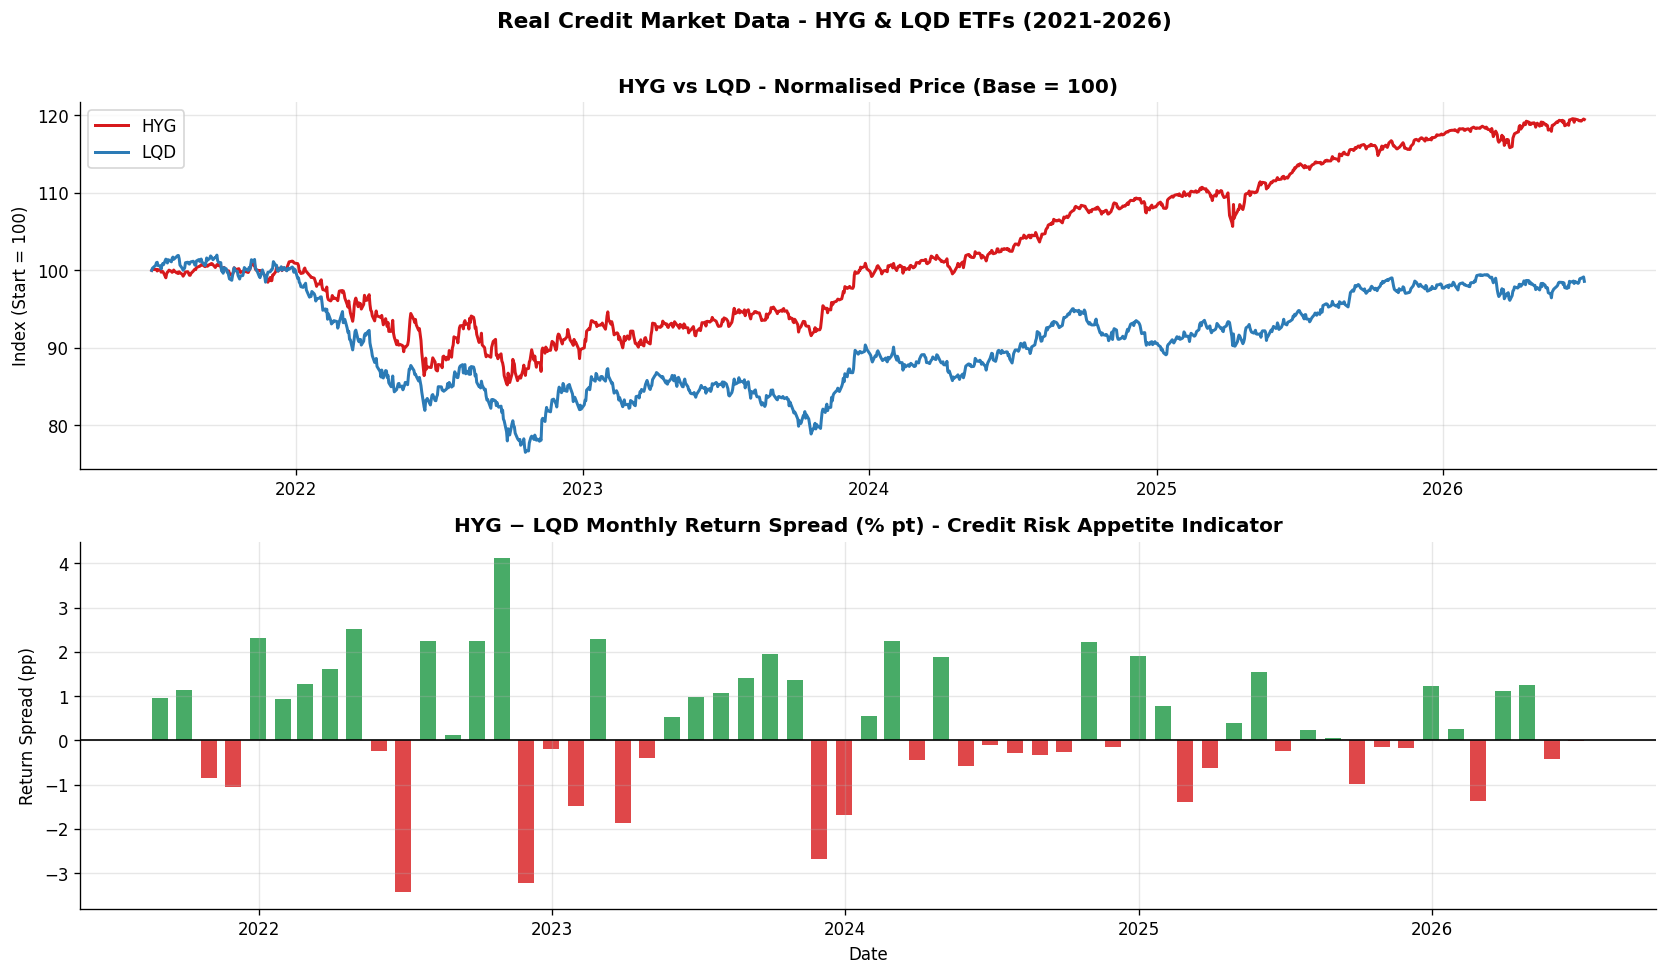


Key observation: negative spikes in the return spread coincide with credit stress episodes.
High-yield bonds are more sensitive to default risk → HYG underperforms LQD in stress.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Panel 1: normalised price levels
norm_prices = prices[TICKERS].dropna() / prices[TICKERS].dropna().iloc[0] * 100
for ticker, col in zip(TICKERS, [RED, BLUE]):
    axes[0].plot(norm_prices.index, norm_prices[ticker], color=col, lw=1.8, label=ticker)
axes[0].set_title('HYG vs LQD - Normalised Price (Base = 100)', fontweight='bold')
axes[0].set_ylabel('Index (Start = 100)')
axes[0].legend(fontsize=10)

# Panel 2: monthly return spread
colors_bar = [RED if v < 0 else GREEN for v in ret['Spread']]
axes[1].bar(ret.index, ret['Spread'] * 100, color=colors_bar, width=20, alpha=0.8)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('HYG − LQD Monthly Return Spread (% pt) - Credit Risk Appetite Indicator',
                  fontweight='bold')
axes[1].set_ylabel('Return Spread (pp)')
axes[1].set_xlabel('Date')

plt.suptitle('Real Credit Market Data - HYG & LQD ETFs (2021-2026)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nKey observation: negative spikes in the return spread coincide with credit stress episodes.")
print("High-yield bonds are more sensitive to default risk → HYG underperforms LQD in stress.")


## 2. Reduced-Form (Intensity) Models

Instead of modelling *why* a firm defaults (Merton's asset process), reduced-form models treat
default as the first jump of a Poisson process with **hazard rate** (default intensity) $\lambda$:

$$S(T) = P(\tau > T) = e^{-\int_0^T \lambda(u)\,du}, \qquad P(\text{default by }T) = 1 - e^{-\lambda T}\;\;(\text{constant }\lambda)$$

**Real, market-implied hazard rates.** We calibrate each rating's hazard from today's traded credit
spread (ICE BofA option-adjusted spreads by rating, pulled from FRED) via the credit triangle
$\lambda \approx s / \text{LGD}$. These are *risk-neutral* intensities (the ones that price CDS).
They sit well above the *real-world* historical default rates, which is exactly the premium we
measured at the end of Session 5.

### The Default-Probability Toolkit: Marginal, Conditional, Unconditional and Hazard

Before we model default *intensity*, we should know the four ways the industry quotes
default probability, and how to move between them. Let $Q(t)$ be the **cumulative** (unconditional)
probability of default by year $t$, and $S(t)=1-Q(t)$ the survival probability.

**The identities (Hull, RMFI Ch.19):**

- **Unconditional / marginal** PD in year $t$ is $Q(t)-Q(t-1)$ (default in that year, seen from today).
- **Conditional** PD in year $t$ is $\dfrac{Q(t)-Q(t-1)}{1-Q(t-1)}=1-\dfrac{S(t)}{S(t-1)}$ (default in year $t$ given survival to $t-1$).
- **Hazard rate** (default intensity) is $\lambda_t=-\ln\dfrac{S(t)}{S(t-1)}$, so $S(t)=e^{-\sum_{u\le t}\lambda_u}$ (the continuous-time limit of the conditional rate).

We can build all of these from **either** of the two data sources this course already uses:
a rating agency's **cumulative default table** (Moody's), or a **one-year transition matrix** $M$
(S&P) raised to powers, $Q_i(t)=\big(M^{t}\big)_{i,\,\text{D}}$. We do both, check they roughly agree,
and then feed the hazard curve straight into a **CVA** calculation.

### Warm-up: a crude A/B/C transition matrix

Before the real S&P matrix, a toy 3-grade example (**A**, **B**, **C**) plus an absorbing
default state **D**. Each row is where an issuer of that grade sits one year later, and the
row sums to 100%. It is diagonal-dominant (ratings are sticky), default risk rises A -> B -> C,
and **D** is absorbing so `M^t[i, D]` gives the cumulative default probability by year *t*.
Loaded from `notebook_data/toy_transition_ABC.csv` (hand-built for teaching, not real data).

One-year transition matrix (%), rows = start grade, cols = grade next year:
                        A     B     C      D
start year/end year                         
A                    92.0   7.0   0.8    0.2
B                     5.0  86.0   7.0    2.0
C                     1.0  12.0  77.0   10.0
D                     0.0   0.0   0.0  100.0

Cumulative default probability Q(t) = (M^t)[grade, D]:
grade       t=1      t=2      t=3      t=5     t=10
A          0.20     0.60     1.21     2.97     9.72
B          2.00     4.43     7.10    12.66    25.60
C         10.00    17.94    24.35    34.01    48.47


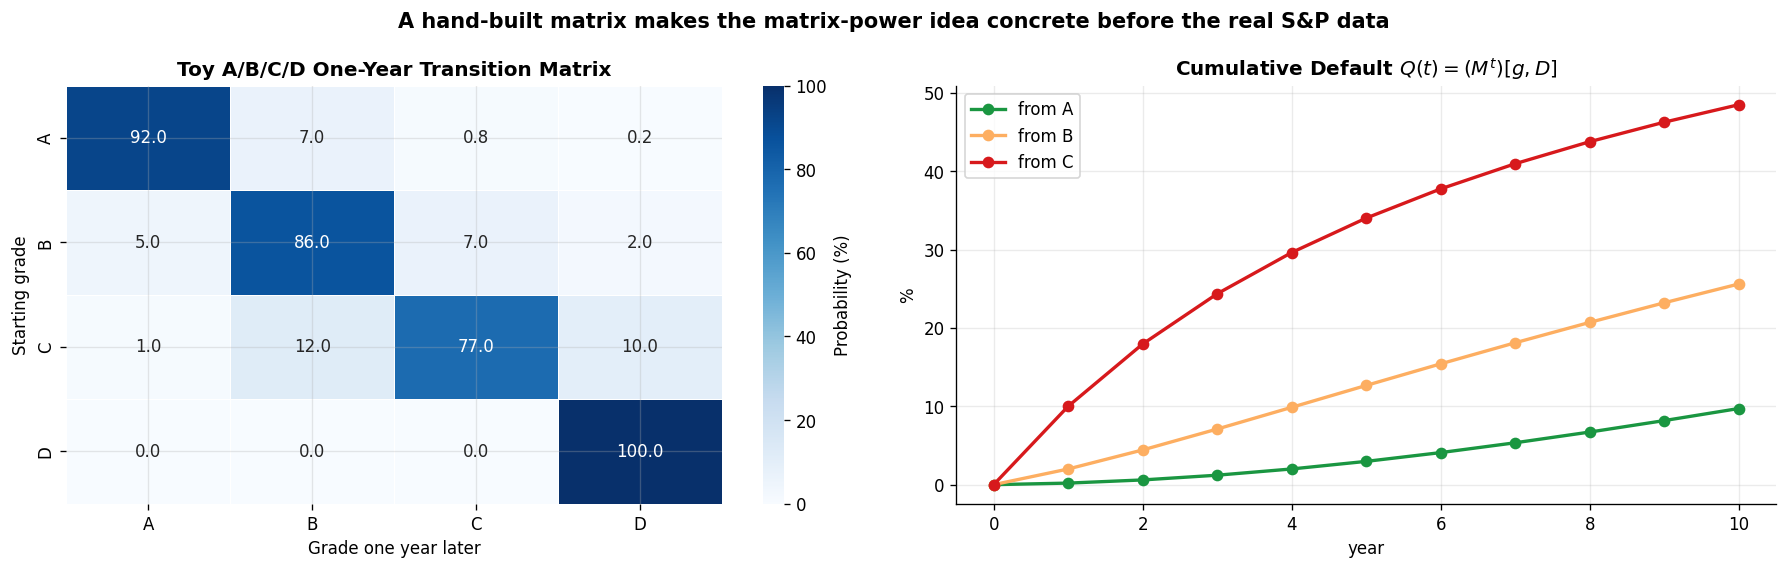


Read-off: a B issuer defaults within 3 years with probability 7.10% (compounded through the matrix, not 3x the 1-year rate).


In [5]:
# -- Toy A/B/C(/D) transition matrix: matrix power -> cumulative default --
toy = pd.read_csv(os.path.join(DATA_DIR, "toy_transition_ABC.csv"), index_col=0)
print("One-year transition matrix (%), rows = start grade, cols = grade next year:")
print(toy.to_string())
assert np.allclose(toy.sum(axis=1), 100), "rows must sum to 100%"

states = list(toy.index)                       # A, B, C, D
Mt = toy.values / 100.0                         # to probabilities
Dcol = states.index("D")                        # absorbing default column

# Cumulative default Q(t) = (M^t)[grade, D] for each starting grade
horizons = [1, 2, 3, 5, 10]
print("\nCumulative default probability Q(t) = (M^t)[grade, D]:")
print(f"{'grade':6s}" + "".join(f"{'t=' + str(t):>9s}" for t in horizons))
for g in ["A", "B", "C"]:
    i = states.index(g)
    row = f"{g:6s}"
    for t in horizons:
        Qt = np.linalg.matrix_power(Mt, t)[i, Dcol] * 100
        row += f"{Qt:>9.2f}"
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
# Panel 1: the matrix as a heatmap
sns.heatmap(toy.values, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=states, yticklabels=states, ax=axes[0],
            cbar_kws={"label": "Probability (%)"}, linewidths=0.4)
axes[0].set_title("Toy A/B/C/D One-Year Transition Matrix", fontweight="bold")
axes[0].set_xlabel("Grade one year later"); axes[0].set_ylabel("Starting grade")
# Panel 2: cumulative default curves
ts = np.arange(0, 11)
for g, col in zip(["A", "B", "C"], [GREEN, GOLD, RED]):
    i = states.index(g)
    Q = [np.linalg.matrix_power(Mt, t)[i, Dcol] * 100 for t in ts]
    axes[1].plot(ts, Q, "o-", color=col, lw=2, label=f"from {g}")
axes[1].set_title("Cumulative Default $Q(t)=(M^t)[g,D]$", fontweight="bold")
axes[1].set_xlabel("year"); axes[1].set_ylabel("%"); axes[1].legend(); axes[1].grid(alpha=0.25)
plt.suptitle("A hand-built matrix makes the matrix-power idea concrete before the real S&P data",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

qB3 = np.linalg.matrix_power(Mt, 3)[states.index("B"), Dcol] * 100
print(f"\nRead-off: a B issuer defaults within 3 years with probability {qB3:.2f}% "
      "(compounded through the matrix, not 3x the 1-year rate).")

Moody's Baa: default-probability toolkit (1970-2013)
 year  cumul Q%  marginal%  condit.%  hazard%  avg haz%
    1     0.174      0.174     0.174    0.174     0.174
    2     0.504      0.330     0.331    0.331     0.253
    3     0.906      0.402     0.404    0.405     0.303
    4     1.373      0.467     0.471    0.472     0.346
    5     1.862      0.489     0.496    0.497     0.376

Moody's B: default-probability toolkit (1970-2013)
 year  cumul Q%  marginal%  condit.%  hazard%  avg haz%
    1     3.904      3.904     3.904    3.982     3.982
    2     9.274      5.370     5.588    5.750     4.866
    3    14.723      5.449     6.006    6.194     5.309
    4    19.509      4.786     5.612    5.776     5.426
    5    23.869      4.360     5.417    5.569     5.454

S&P matrix BBB (via matrix powers M^t): default-probability toolkit (1981-2024)
 year  cumul Q%  marginal%  condit.%  hazard%
    1     0.148      0.148     0.148    0.149
    2     0.352      0.204     0.204    0.204
    

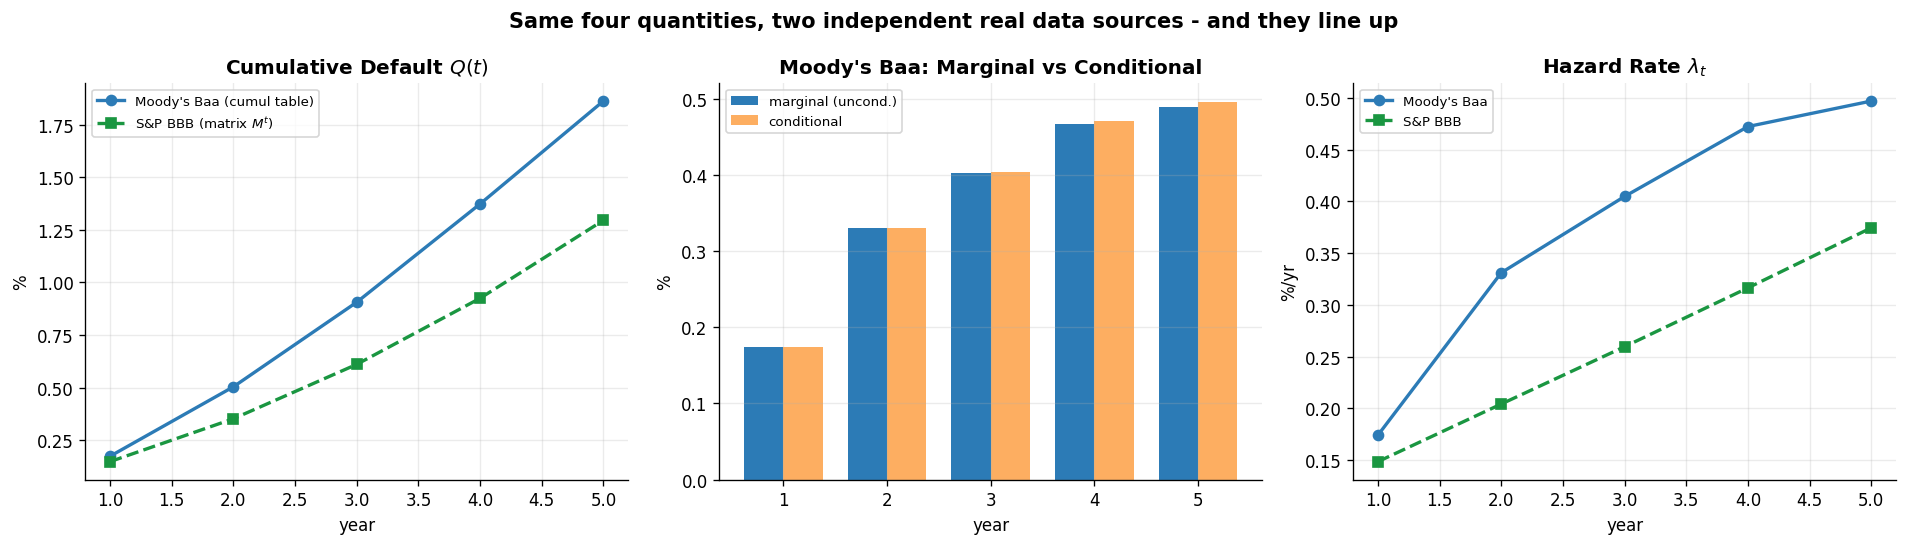


Marginal < conditional because conditioning on survival divides by the shrinking survival
base. Both agencies put the BBB/Baa hazard near 0.4-0.5%/yr, rising with horizon - investment
grade default risk builds slowly. The hazard curve is exactly the lambda our intensity models use.


In [6]:
# --- Route 1: from the REAL Moody's cumulative default table ---
cum = pd.read_csv(os.path.join(DATA_DIR, "moodys_cum_default_1970_2013.csv"), index_col=0)
yrs = [1,2,3,4,5]                                   # consecutive years -> clean marginals
def toolkit_from_cum(rating):
    Q = np.array([0.0] + [cum.loc[rating, str(y)]/100 for y in yrs])   # cumulative, Q(0)=0
    S = 1 - Q
    marg = np.diff(Q)                                                  # unconditional / marginal
    cond = marg / S[:-1]                                               # conditional (given survival)
    haz  = -np.log(S[1:] / S[:-1])                                     # hazard (intensity)
    return Q[1:], marg, cond, haz

for rating in ["Baa","B"]:
    Q, marg, cond, haz = toolkit_from_cum(rating)
    print(f"Moody's {rating}: default-probability toolkit (1970-2013)")
    print(f"{'year':>5s}{'cumul Q%':>10s}{'marginal%':>11s}{'condit.%':>10s}{'hazard%':>9s}{'avg haz%':>10s}")
    for i,y in enumerate(yrs):
        avg = -np.log(1-Q[i])/y*100
        print(f"{y:>5d}{Q[i]*100:>10.3f}{marg[i]*100:>11.3f}{cond[i]*100:>10.3f}{haz[i]*100:>9.3f}{avg:>10.3f}")
    print()

# --- Route 2: from the REAL S&P transition matrix via matrix powers ---
tr = pd.read_csv(os.path.join(DATA_DIR, "sp_transition_1981_2024.csv"), index_col=0)
frm = ['AAA','AA','A','BBB','BB','B','CCC/C']             # from-ratings (rows); D has no row
st  = frm + ['D']                                        # to-states kept (drop NR)
sub = tr.loc[frm, st].values.astype(float)               # 7x8, keeps D column, drops NR
sub = sub / sub.sum(axis=1, keepdims=True)               # renormalise each row (NR removed)
M   = np.zeros((8, 8)); M[:7] = sub; M[7, 7] = 1.0       # add absorbing Default row
D = 7
def toolkit_from_matrix(rating, T=5):
    i = frm.index(rating)
    Q = np.array([0.0] + [np.linalg.matrix_power(M, t)[i, D] for t in range(1, T+1)])
    S = 1 - Q
    return Q[1:], np.diff(Q), np.diff(Q)/S[:-1], -np.log(S[1:]/S[:-1])

Qm, margm, condm, hazm = toolkit_from_matrix("BBB")
print("S&P matrix BBB (via matrix powers M^t): default-probability toolkit (1981-2024)")
print(f"{'year':>5s}{'cumul Q%':>10s}{'marginal%':>11s}{'condit.%':>10s}{'hazard%':>9s}")
for i in range(5):
    print(f"{i+1:>5d}{Qm[i]*100:>10.3f}{margm[i]*100:>11.3f}{condm[i]*100:>10.3f}{hazm[i]*100:>9.3f}")

# --- Compare the two routes + show the shapes ---
Qb, margb, condb, hazb = toolkit_from_cum("Baa")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
axes[0].plot(yrs, Qb*100, 'o-', color=BLUE, lw=2, label="Moody's Baa (cumul table)")
axes[0].plot(yrs, Qm*100, 's--', color=GREEN, lw=2, label="S&P BBB (matrix $M^t$)")
axes[0].set_title("Cumulative Default $Q(t)$", fontweight='bold'); axes[0].set_xlabel("year")
axes[0].set_ylabel("%"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)
w=0.38
axes[1].bar([y-w/2 for y in yrs], margb*100, w, color=BLUE, label="marginal (uncond.)")
axes[1].bar([y+w/2 for y in yrs], condb*100, w, color=GOLD, label="conditional")
axes[1].set_title("Moody's Baa: Marginal vs Conditional", fontweight='bold'); axes[1].set_xlabel("year")
axes[1].set_ylabel("%"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
axes[2].plot(yrs, hazb*100, 'o-', color=BLUE, lw=2, label="Moody's Baa")
axes[2].plot(yrs, hazm*100, 's--', color=GREEN, lw=2, label="S&P BBB")
axes[2].set_title("Hazard Rate $\\lambda_t$", fontweight='bold'); axes[2].set_xlabel("year")
axes[2].set_ylabel("%/yr"); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.25)
plt.suptitle("Same four quantities, two independent real data sources - and they line up",
             fontsize=12.5, fontweight='bold'); plt.tight_layout(); plt.show()
print("\nMarginal < conditional because conditioning on survival divides by the shrinking survival")
print("base. Both agencies put the BBB/Baa hazard near 0.4-0.5%/yr, rising with horizon - investment")
print("grade default risk builds slowly. The hazard curve is exactly the lambda our intensity models use.")

### Window sensitivity of the hazard toolkit: 1970-2013 vs 1983-2023

The intensity models take **lambda** straight from the cumulative default table, so swapping
the sample window rescales every hazard. Below we run the same cumulative-default and
average-hazard read on Moody's **1970-2013** and **1983-2023** tables for Baa and B (horizons
common to both). The recent window gives a lower speculative-grade hazard. This is a reminder that
the input PD table is itself a modelling choice.

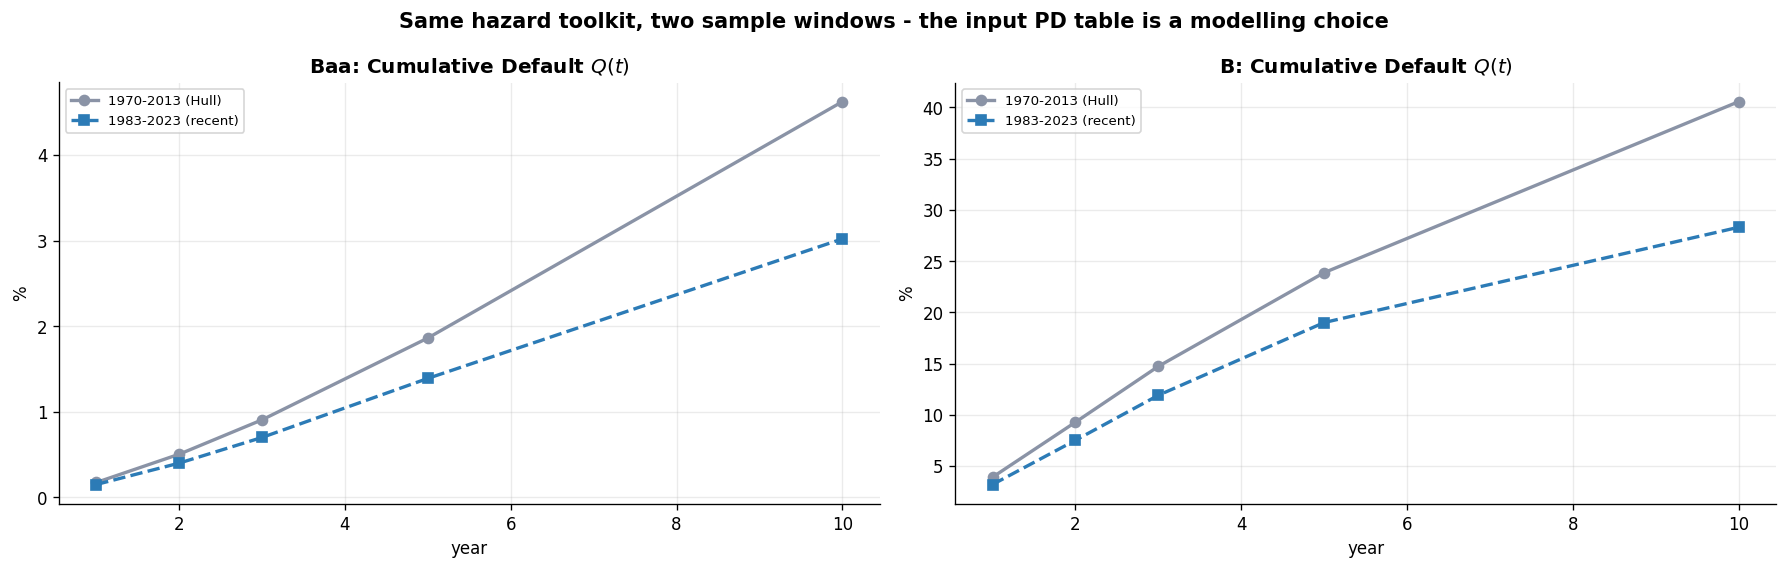

Average hazard  -ln(1-Q)/t  (%/yr):  1970-2013  vs  1983-2023
rating   yr   old haz%   new haz%
Baa       5      0.376      0.280
Baa      10      0.473      0.307
B         5      5.454      4.214
B        10      5.202      3.327
(1983-2023 figures are approximate, years 1/2/3/5/10 only - verify before graded use.)


In [7]:
# -- Window sensitivity: same hazard toolkit on two Moody's windows --
cum_new = pd.read_csv(os.path.join(DATA_DIR, "moodys_cum_default_1983_2023.csv"), index_col=0)
cum_old = cum                                    # 1970-2013, loaded in the cell above
Hs = [1, 2, 3, 5, 10]                            # horizons common to both tables

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, rating in zip(axes, ["Baa", "B"]):
    Qo = np.array([cum_old.loc[rating, str(h)] for h in Hs])
    Qn = np.array([cum_new.loc[rating, str(h)] for h in Hs])
    ax.plot(Hs, Qo, "o-",  color="#8A93A6", lw=2, label="1970-2013 (Hull)")
    ax.plot(Hs, Qn, "s--", color=BLUE,      lw=2, label="1983-2023 (recent)")
    ax.set_title(f"{rating}: Cumulative Default $Q(t)$", fontweight="bold")
    ax.set_xlabel("year"); ax.set_ylabel("%"); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.suptitle("Same hazard toolkit, two sample windows - the input PD table is a modelling choice",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

print("Average hazard  -ln(1-Q)/t  (%/yr):  1970-2013  vs  1983-2023")
print(f"{'rating':7s}{'yr':>4s}{'old haz%':>11s}{'new haz%':>11s}")
for rating in ["Baa", "B"]:
    for h in [5, 10]:
        ho = -np.log(1 - cum_old.loc[rating, str(h)]/100)/h*100
        hn = -np.log(1 - cum_new.loc[rating, str(h)]/100)/h*100
        print(f"{rating:7s}{h:>4d}{ho:>11.3f}{hn:>11.3f}")
print("(1983-2023 figures are approximate, years 1/2/3/5/10 only - verify before graded use.)")

#### From the hazard curve to CVA

The hazard curve is all we need to value the credit risk of an exposure. Split the horizon into
periods; the **marginal** default probability in period $t$ is $q_t=S(t-1)-S(t)$, and the credit
value adjustment is the present value of expected default losses:

$$\text{CVA}=\sum_t \underbrace{q_t}_{\text{marginal PD}}\times \text{LGD}\times \underbrace{EE_t}_{\text{expected exposure}}\times \underbrace{DF_t}_{\text{discount}}$$

The **same formula** gives two different numbers depending on which hazard curve you feed it: a
**risk-neutral** curve (from CDS/bond spreads) prices the **CVA / market charge**, while a
**real-world** curve (from the Moody's/S&P tables above) gives the **expected credit loss** (the
actuarial / IFRS 9 number). The gap between them is the credit-risk premium.

Credit spreads pulled LIVE from FRED: 793 days, 2023-07-14 to 2026-07-10.
5-year BBB bond, LGD 60%, face 100, discount 4.27% (5y Treasury, FRED)
  risk-neutral hazard  lam=1.60%/yr  -> CVA (price / market charge) = 4.138
  real-world hazard    lam~0.26%/yr -> expected credit loss        = 0.683
  wedge (credit-risk premium) = +3.454  ~ 69.1 bp/yr

  CVA-implied running spread ~ 83 bp/yr   vs  lambda x LGD shortcut = 96 bp/yr


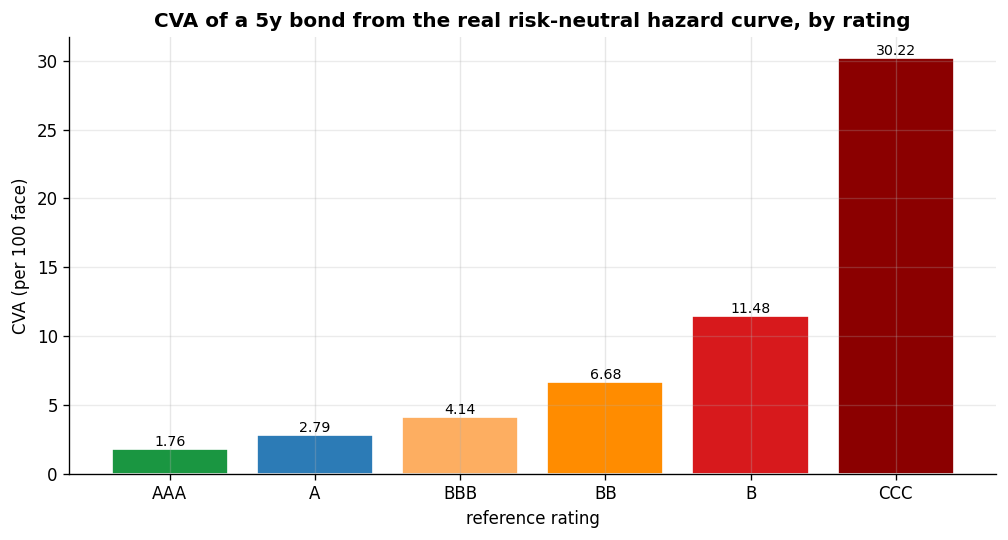


This is the building block: a flat exposure and a hazard curve. Section 10 (CVA) extends the
SAME formula to a counterparty swap whose exposure EE_t is a simulated profile, not a constant.


In [8]:
# --- CVA on a simple bond exposure, straight from a hazard curve ---
def cva_from_hazard(lam_annual, LGD=0.60, EAD=100.0, r=RF_ANNUAL, T=5, steps_per_yr=4):
    """Discrete CVA = sum over periods of  marginal PD x LGD x exposure x discount."""
    lam = np.asarray(lam_annual, float)                       # per-year hazard, length T
    dt  = 1.0/steps_per_yr; cva = 0.0; S_prev = 1.0
    for k in range(1, T*steps_per_yr+1):
        yr = int(np.ceil(k*dt)-1e-9); yr = min(max(yr,0), T-1)
        S_now = S_prev*np.exp(-lam[yr]*dt)
        q     = S_prev - S_now                                # marginal PD this step
        cva  += q * LGD * EAD * np.exp(-r*k*dt)               # EE ~ EAD (bullet bond)
        S_prev = S_now
    return cva

LGD = 0.60; T = 5
rf = fred_rf(T)          # risk-free = 5y Treasury (FRED, DGS5) to match the 5-year bond horizon
# risk-neutral hazard by rating from today's real FRED OAS (lambda ~ spread / LGD) -> a PRICE
_oas = fred_spreads().dropna(how="all").iloc[-1]
_col = {"AAA":"AAA","A":"A_","BBB":"BBB","BB":"BB","B":"B","CCC":"CCC"}
lam_mkt = {r: float(_oas[c])/100/LGD for r, c in _col.items()}      # risk-neutral hazards
lam_rn = np.full(T, lam_mkt["BBB"])
# real-world BBB hazard from the S&P matrix (per-year) -> an EXPECTED LOSS
lam_rw = hazm[:T]

cva_price = cva_from_hazard(lam_rn, LGD=LGD, r=rf, T=T)
cva_el    = cva_from_hazard(lam_rw, LGD=LGD, r=rf, T=T)
print(f"5-year BBB bond, LGD {LGD:.0%}, face 100, discount {rf:.2%} (5y Treasury, FRED)")
print(f"  risk-neutral hazard  lam={lam_rn[0]*100:.2f}%/yr  -> CVA (price / market charge) = {cva_price:.3f}")
print(f"  real-world hazard    lam~{lam_rw.mean()*100:.2f}%/yr -> expected credit loss        = {cva_el:.3f}")
print(f"  wedge (credit-risk premium) = {cva_price-cva_el:+.3f}  ~ {(cva_price-cva_el)/T*100:.1f} bp/yr")
# sanity: CVA as a running spread vs the s = lambda x LGD shortcut
print(f"\n  CVA-implied running spread ~ {cva_price/T/100*1e4:.0f} bp/yr   "
      f"vs  lambda x LGD shortcut = {lam_rn[0]*LGD*1e4:.0f} bp/yr")

# sweep CVA across the real by-rating hazards (risk-neutral)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
rates = ["AAA","A","BBB","BB","B","CCC"]
cvas  = [cva_from_hazard(np.full(T, lam_mkt[r]), LGD=LGD, r=rf, T=T) for r in rates]
ax.bar(rates, cvas, color=[GREEN,BLUE,GOLD,'darkorange',RED,'#8B0000'], edgecolor='white')
for i,v in enumerate(cvas): ax.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=8.5)
ax.set_ylabel("CVA (per 100 face)"); ax.set_xlabel("reference rating")
ax.set_title("CVA of a 5y bond from the real risk-neutral hazard curve, by rating", fontweight='bold')
ax.grid(alpha=0.25, axis='y'); plt.tight_layout(); plt.show()
print("\nThis is the building block: a flat exposure and a hazard curve. Section 10 (CVA) extends the")
print("SAME formula to a counterparty swap whose exposure EE_t is a simulated profile, not a constant.")

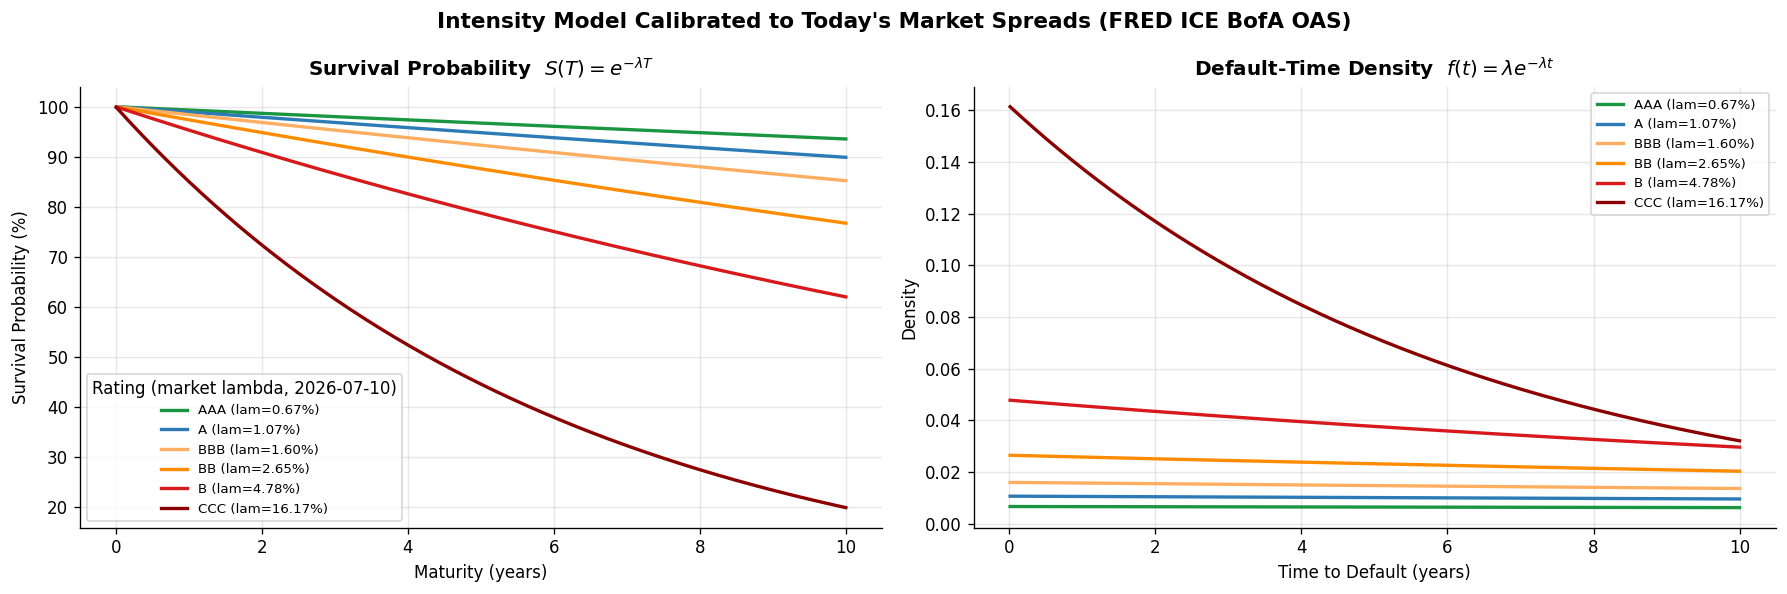

Market-implied (risk-neutral) vs historical (real-world) 1-yr default, spreads 2026-07-10
Rating | OAS (bps) | RN lambda |  RN PD % | Real-world PD %
AAA    |        40 |     0.67% |    0.66% |            0.00
A      |        64 |     1.07% |    1.06% |            0.06
BBB    |        96 |     1.60% |    1.59% |            0.17
BB     |       159 |     2.65% |    2.62% |            1.11
B      |       287 |     4.78% |    4.67% |            3.90
CCC    |       970 |    16.17% |   14.93% |           15.89


In [9]:
# --- 2a. Survival curves from REAL market-implied hazard rates ---
# Risk-neutral hazard by rating from today's ICE BofA OAS (FRED):  lambda ~ spread / LGD
fred = fred_spreads()
oas_latest = fred.dropna(how="all").iloc[-1]
oas_asof   = fred.dropna(how="all").index[-1].date()
LGD_RN = 0.60
col_by_rating = {"AAA":"AAA","A":"A_","BBB":"BBB","BB":"BB","B":"B","CCC":"CCC"}
lam_by_rating = {r: float(oas_latest[c])/100/LGD_RN for r,c in col_by_rating.items()}
rating_lambda = {f"{r} (lam={lam*100:.2f}%)": lam for r,lam in lam_by_rating.items()}

maturities = np.linspace(0.01, 10, 300)
colors_rng = [GREEN, BLUE, GOLD, "darkorange", RED, "#8B0000"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for (label, lam), col in zip(rating_lambda.items(), colors_rng):
    axes[0].plot(maturities, np.exp(-lam*maturities)*100, color=col, lw=2, label=label)
    axes[1].plot(maturities, lam*np.exp(-lam*maturities), color=col, lw=2, label=label)
axes[0].set_title("Survival Probability  $S(T)=e^{-\\lambda T}$", fontweight="bold")
axes[0].set_xlabel("Maturity (years)"); axes[0].set_ylabel("Survival Probability (%)")
axes[0].legend(fontsize=8, title=f"Rating (market lambda, {oas_asof})")
axes[1].set_title("Default-Time Density  $f(t)=\\lambda e^{-\\lambda t}$", fontweight="bold")
axes[1].set_xlabel("Time to Default (years)"); axes[1].set_ylabel("Density"); axes[1].legend(fontsize=8)
plt.suptitle("Intensity Model Calibrated to Today's Market Spreads (FRED ICE BofA OAS)",
             fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()

# Risk-neutral (market) vs real-world (historical) hazard - the credit-risk premium
cum_def = pd.read_csv(os.path.join(DATA_DIR, "moodys_cum_default_1970_2013.csv"), index_col=0)
hist_map = {"AAA":"Aaa","A":"A","BBB":"Baa","BB":"Ba","B":"B","CCC":"Caa-C"}
print(f"Market-implied (risk-neutral) vs historical (real-world) 1-yr default, spreads {oas_asof}")
print(f"{'Rating':6s} | {'OAS (bps)':>9s} | {'RN lambda':>9s} | {'RN PD %':>8s} | {'Real-world PD %':>15s}")
for r,c in col_by_rating.items():
    lam = lam_by_rating[r]; rn_pd = (1-np.exp(-lam))*100
    rw = cum_def.loc[hist_map[r], "1"]
    print(f"{r:6s} | {oas_latest[c]*100:9.0f} | {lam*100:8.2f}% | {rn_pd:7.2f}% | {rw:15.2f}")

Simulated 50,000 default-time paths using today's market hazards.

BB (lam=0.0265/yr): sim P(default<=10y)=23.07%  analytical=23.28%  median tau=26.24y

B (lam=0.0478/yr): sim P(default<=10y)=37.85%  analytical=38.02%  median tau=14.54y


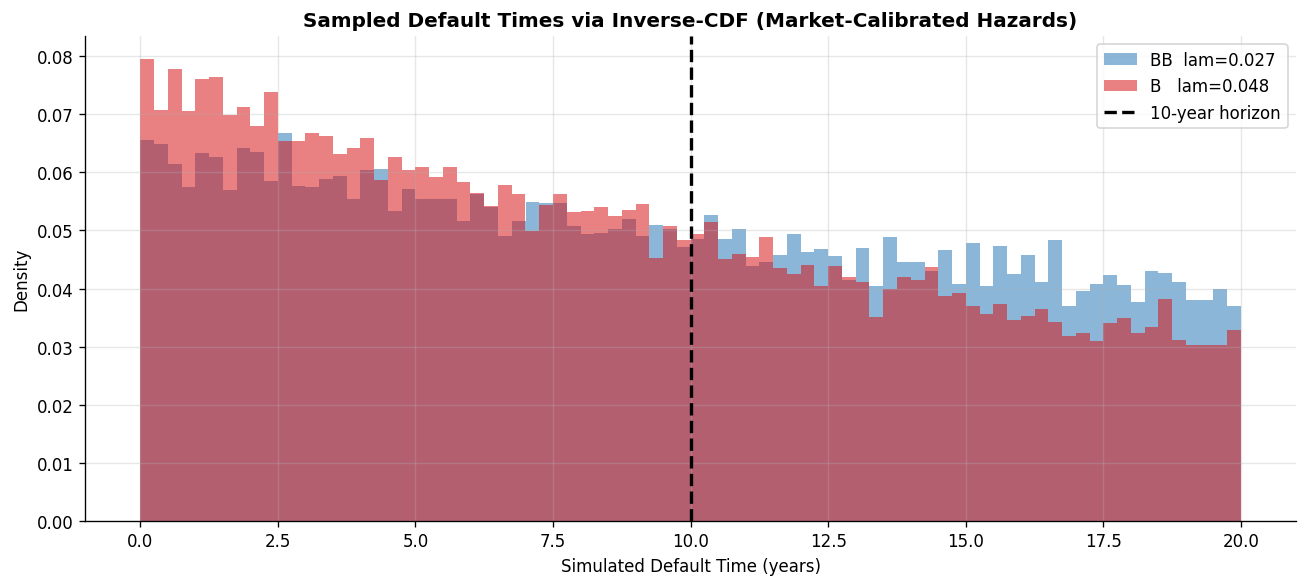

In [10]:
# --- 2b. Sampling default times via inverse-CDF (real BB & B intensities) ---
np.random.seed(42)
N_PATHS = 50_000
HORIZON = 10.0
lam_bb = lam_by_rating["BB"]   # market-implied BB hazard (from FRED OAS)
lam_b  = lam_by_rating["B"]    # market-implied B  hazard

U = np.random.uniform(0, 1, N_PATHS)
tau_bb = -np.log(U) / lam_bb
tau_b  = -np.log(U) / lam_b

print(f"Simulated {N_PATHS:,} default-time paths using today's market hazards.")
for tag, lam, tau in [("BB", lam_bb, tau_bb), ("B", lam_b, tau_b)]:
    sim = (tau <= HORIZON).mean()*100; ana = (1-np.exp(-lam*HORIZON))*100
    print(f"\n{tag} (lam={lam:.4f}/yr): sim P(default<={HORIZON:.0f}y)={sim:.2f}%  "
          f"analytical={ana:.2f}%  median tau={np.median(tau):.2f}y")

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(tau_bb[tau_bb<=HORIZON*2], bins=80, density=True, alpha=0.55, color=BLUE, label=f"BB  lam={lam_bb:.3f}")
ax.hist(tau_b[tau_b<=HORIZON*2],   bins=80, density=True, alpha=0.55, color=RED,  label=f"B   lam={lam_b:.3f}")
ax.axvline(HORIZON, color="black", ls="--", lw=2, label=f"{HORIZON:.0f}-year horizon")
ax.set_xlabel("Simulated Default Time (years)"); ax.set_ylabel("Density")
ax.set_title("Sampled Default Times via Inverse-CDF (Market-Calibrated Hazards)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

## 3. CDS Pricing & Hazard-Curve Bootstrapping

A CDS premium leg (buyer pays $s$ until default) must equal the protection leg (seller pays
$\text{LGD}$ at default). Setting them equal and solving for $s$ gives the fair spread; inverting
the relationship lets us **bootstrap** a term structure of hazard rates from observed spreads.

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:13px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:6px;">Bootstrapped from a real spread term structure</div>
<div style="color:#B8D4E8;line-height:1.7;">Instead of made-up quotes, we bootstrap the hazard curve from the <strong>real ICE BofA
US investment-grade corporate OAS by maturity bucket</strong> (1-3y, 3-5y, 5-7y, 7-10y, 10-15y),
pulled from FRED. OAS is a cash-bond spread and differs from a pure CDS spread by a basis, but its
<em>term structure</em> is exactly what the bootstrap consumes, and it is genuinely observable today.</div>
</div>

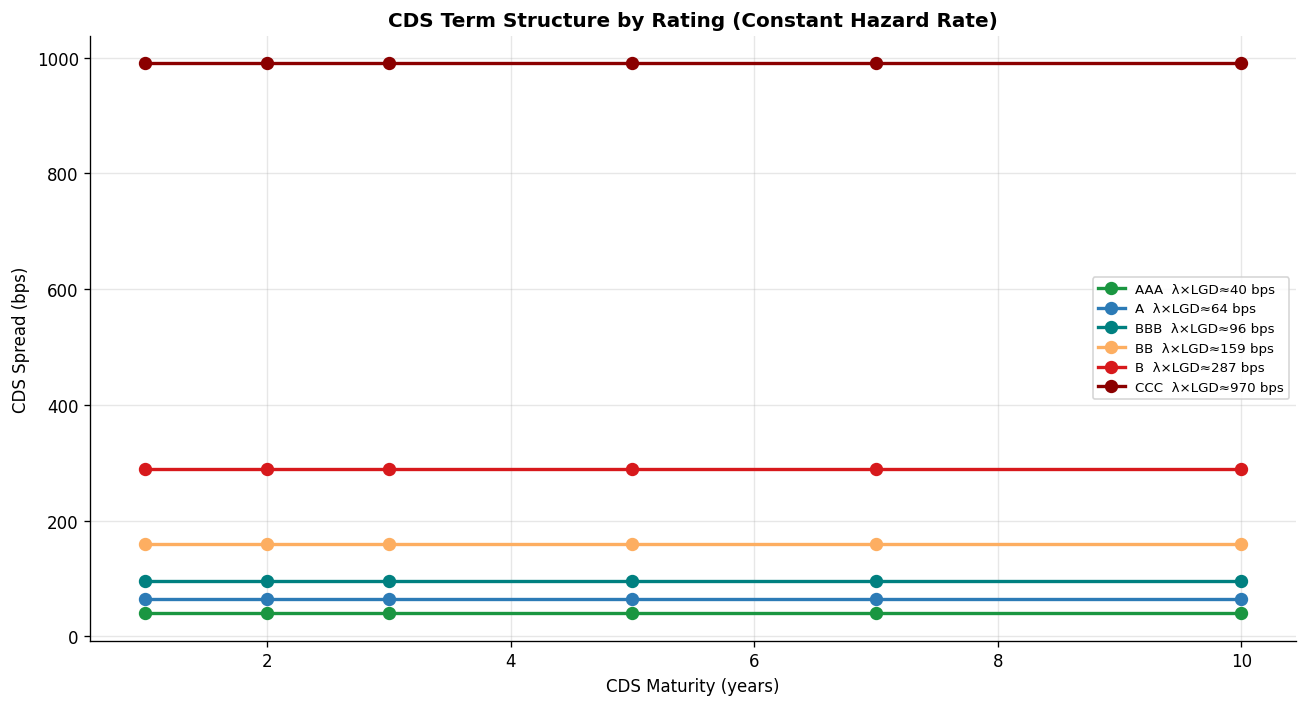

Approximation check: s_CDS ≈ (1−R)·λ = LGD·λ
Rating | λ      | LGD×λ (bps)  | Model 5yr (bps) 
AAA    | 0.0067 |         40.0 |             40.0
A      | 0.0107 |         64.0 |             64.1
BBB    | 0.0160 |         96.0 |             96.2
BB     | 0.0265 |        159.0 |            159.5
B      | 0.0478 |        287.0 |            288.7
CCC    | 0.1617 |        970.0 |            989.9


In [11]:
def cds_spread_bps(lam_seg, t_knots, lgd, r, T_cds, freq=4):
    """
    Price a CDS given piecewise-constant hazard rates.
    lam_seg  : list of hazard rates for each knot interval
    t_knots  : sorted knot times (must include 0)
    lgd, r, T_cds: LGD, risk-free rate, CDS maturity
    """
    dt    = 1.0 / freq
    times = np.arange(dt, T_cds + dt/2, dt)

    def surv(t):
        """Survival probability at time t under piecewise-constant hazard."""
        s = 0.0
        for k in range(len(t_knots) - 1):
            t0, t1 = t_knots[k], t_knots[k + 1]
            if t <= t0:
                break
            s += lam_seg[k] * (min(t, t1) - t0)
        return np.exp(-s)

    survs = np.array([surv(t) for t in times])
    dfs   = np.exp(-r * times)
    premium_leg = dt * (survs * dfs).sum()
    prev_survs  = np.concatenate([[1.0], survs[:-1]])
    protection_leg = lgd * ((prev_survs - survs) * dfs).sum()
    if premium_leg <= 0:
        return np.nan
    return (protection_leg / premium_leg) * 10000  # bps


# Constant-hazard (single-segment) CDS term structure by rating (market-implied λ)
lgd_cds = 0.60
rf      = fred_rf(5)     # risk-free = 5y Treasury (FRED, DGS5); 5y is the benchmark CDS tenor
r_cds   = rf
mats    = [1, 2, 3, 5, 7, 10]
colors_r = [GREEN, BLUE, 'teal', GOLD, RED, '#8B0000']

fig, ax = plt.subplots(figsize=(11, 6))
for (label, lam), col in zip(rating_lambda.items(), colors_r):
    knots = [0.0, 15.0]   # one flat segment
    spreads = [cds_spread_bps([lam], knots, lgd_cds, r_cds, T) for T in mats]
    short_lbl = label.split('(')[0].strip()
    ax.plot(mats, spreads, 'o-', color=col, lw=2, ms=7,
            label=f'{short_lbl}  λ×LGD≈{lam*lgd_cds*1e4:.0f} bps')

ax.set_xlabel('CDS Maturity (years)')
ax.set_ylabel('CDS Spread (bps)')
ax.set_title('CDS Term Structure by Rating (Constant Hazard Rate)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Approximation check: s_CDS ≈ (1−R)·λ = LGD·λ")
print(f"{'Rating':6s} | {'λ':6s} | {'LGD×λ (bps)':12s} | {'Model 5yr (bps)':16s}")
for (label, lam), col in zip(rating_lambda.items(), colors_r):
    approx = lam * lgd_cds * 1e4
    model  = cds_spread_bps([lam], [0.0, 15.0], lgd_cds, r_cds, 5)
    short  = label.split('(')[0].strip()
    print(f"{short:6s} | {lam:.4f} | {approx:12.1f} | {model:16.1f}")


Bootstrapped hazard curve from real IG corporate OAS term structure:
Segment        | OAS (bps) | lambda (%/yr)
0.0- 2.0 yr   |        48 |        0.7992
2.0- 4.0 yr   |        66 |        1.4318
4.0- 6.0 yr   |        79 |        1.8282
6.0- 8.5 yr   |        93 |        2.2714
8.5-12.5 yr   |        93 |        1.5470


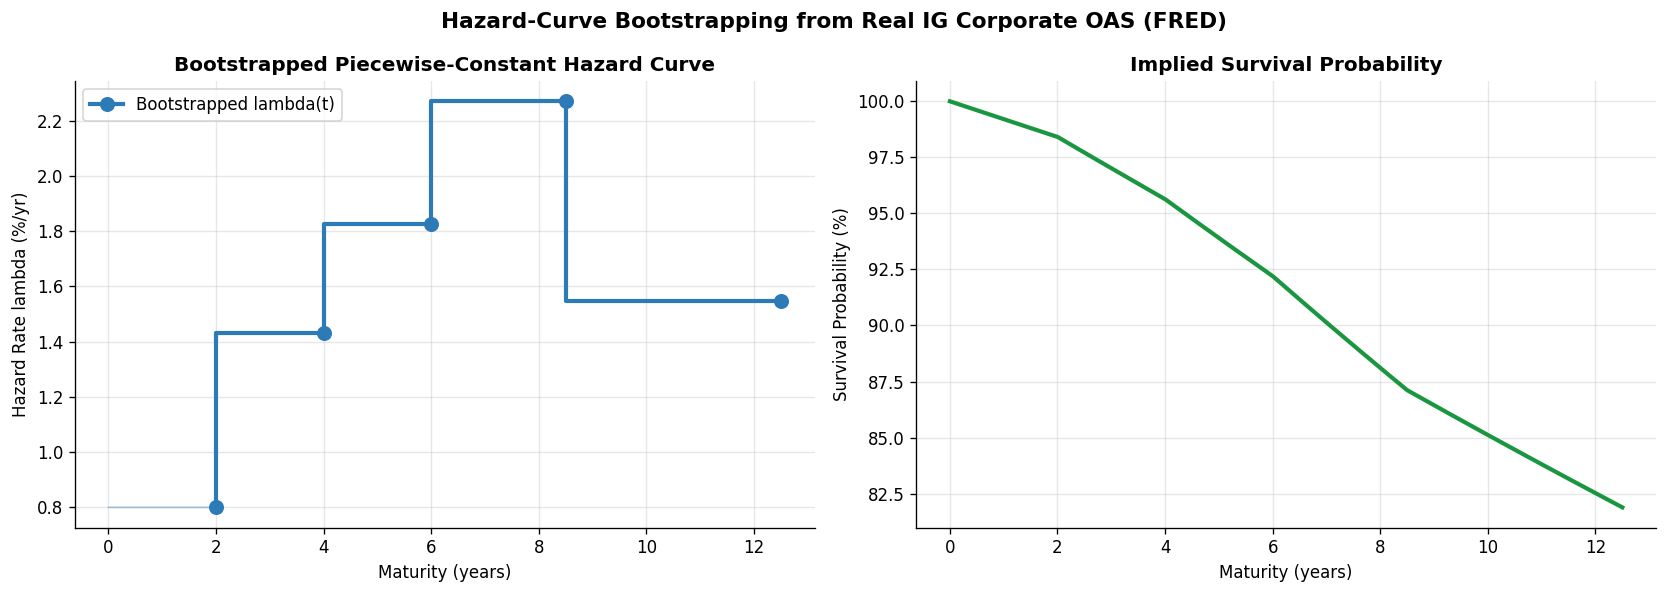


Upward-sloping hazard curve: the market prices rising default risk at longer horizons,
the typical shape for investment-grade credit.


In [12]:
# --- Bootstrap a hazard curve from a REAL spread term structure ---
# ICE BofA US IG corporate OAS by maturity bucket (FRED), most recent day.
_lb = fred_spreads().dropna(how="all").iloc[-1]
buckets = [("IG_1_3y", 2.0), ("IG_3_5y", 4.0), ("IG_5_7y", 6.0),
           ("IG_7_10y", 8.5), ("IG_10_15y", 12.5)]
market_quotes = {tenor: float(_lb[col])*100 for col, tenor in buckets}   # bps at each tenor
lgd_boot = 0.60
r_boot   = RF_ANNUAL

knot_mats = sorted(market_quotes.keys())
t_knots   = [0.0] + knot_mats
lam_boot  = []
for i, T in enumerate(knot_mats):
    target = market_quotes[T]; cur = lam_boot.copy()
    def objective(lam_new):
        return cds_spread_bps(cur+[lam_new], t_knots[:i+2], lgd_boot, r_boot, T) - target
    try:
        lam_new = brentq(objective, 1e-6, 0.80, xtol=1e-8)
    except ValueError:
        lam_new = target/1e4/lgd_boot
    lam_boot.append(lam_new)

print("Bootstrapped hazard curve from real IG corporate OAS term structure:")
print(f"{'Segment':14s} | {'OAS (bps)':>9s} | {'lambda (%/yr)':>13s}")
for i, T in enumerate(knot_mats):
    print(f"{t_knots[i]:.1f}-{T:>4.1f} yr   | {market_quotes[T]:9.0f} | {lam_boot[i]*100:13.4f}")

t_plot = np.linspace(0, 12.5, 500); lam_plot = np.zeros_like(t_plot)
for i,(t0,t1) in enumerate(zip(t_knots[:-1], t_knots[1:])):
    lam_plot[(t_plot>=t0)&(t_plot<t1)] = lam_boot[i]*100
lam_plot[t_plot>=t_knots[-1]] = lam_boot[-1]*100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].step(t_knots[1:], [l*100 for l in lam_boot], where="pre", color=BLUE, lw=2.5,
             marker="o", ms=8, label="Bootstrapped lambda(t)")
axes[0].plot(t_plot, lam_plot, color=BLUE, lw=1, alpha=0.4)
axes[0].set_xlabel("Maturity (years)"); axes[0].set_ylabel("Hazard Rate lambda (%/yr)")
axes[0].set_title("Bootstrapped Piecewise-Constant Hazard Curve", fontweight="bold"); axes[0].legend()

def surv_boot(t):
    s=0.0
    for k in range(len(t_knots)-1):
        t0b,t1b=t_knots[k],t_knots[k+1]
        if t<=t0b: break
        s += lam_boot[k]*(min(t,t1b)-t0b)
    return np.exp(-s)
t_surv=np.linspace(0,12.5,400)
axes[1].plot(t_surv, [surv_boot(t)*100 for t in t_surv], color=GREEN, lw=2.5)
axes[1].set_xlabel("Maturity (years)"); axes[1].set_ylabel("Survival Probability (%)")
axes[1].set_title("Implied Survival Probability", fontweight="bold")
plt.suptitle("Hazard-Curve Bootstrapping from Real IG Corporate OAS (FRED)",
             fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()
print("\nUpward-sloping hazard curve: the market prices rising default risk at longer horizons,")
print("the typical shape for investment-grade credit.")

## 3b. CDS in Practice: Credit Events and Settlement

The pricing above assumes a payout on default. In practice a single-name CDS pays only when a
defined **credit event** occurs, and the size of the payment is set by an **auction**:

- **Credit events (ISDA):** bankruptcy, failure to pay, and restructuring (the last mainly in Europe).
- **Settlement:** an ISDA auction fixes one recovery `R` for all contracts on the name.
  - *Cash:* protection buyer receives `Notional x (1 - R)`.
  - *Physical:* buyer delivers defaulted bonds (face = notional) and receives par.

Auctions replaced pure physical settlement once CDS notional outgrew the deliverable bonds.

Three ISDA credit events that can trigger a single-name CDS:
  - Bankruptcy
  - Failure to pay
  - Restructuring (soft / mod-mod, mainly Europe)

Settlement: an ISDA auction fixes ONE recovery R for every contract on the name.
Cash payout = Notional x (1 - R).   Notional = $10,000,000

  Auction recovery R   LGD = 1-R     Cash payout
                20%         80%       8,000,000
                40%         60%       6,000,000
                60%         40%       4,000,000

Worked case: auction recovery 40%  ->  cash payout $6,000,000.
Physical settlement is equivalent: the buyer delivers $10,000,000 face of bonds (worth
40% = $4,000,000) and receives par $10,000,000 -> same $6,000,000 of protection.


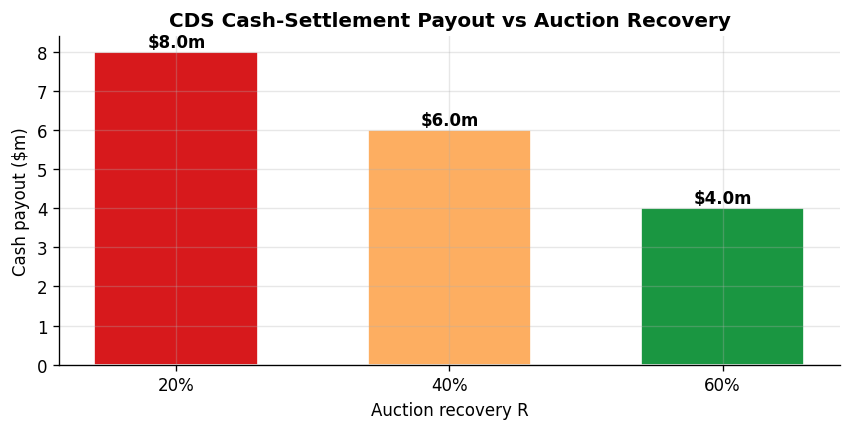


Lower recovery -> larger protection payout. The auction turns a messy default into a single,
market-agreed number so every CDS on the name settles consistently.


In [13]:
# --- CDS settlement: from a credit event to a cash payout ---
BLUE=globals().get("BLUE","#2E6E9E"); GREEN=globals().get("GREEN","#2ca25f")
RED=globals().get("RED","#c0392b"); GOLD=globals().get("GOLD","#d9a441")

NOTIONAL = 10_000_000
print("Three ISDA credit events that can trigger a single-name CDS:")
for ev in ["Bankruptcy", "Failure to pay", "Restructuring (soft / mod-mod, mainly Europe)"]:
    print("  -", ev)
print("\nSettlement: an ISDA auction fixes ONE recovery R for every contract on the name.")
print(f"Cash payout = Notional x (1 - R).   Notional = ${NOTIONAL:,.0f}\n")
print(f"{'Auction recovery R':>20s}{'LGD = 1-R':>12s}{'Cash payout':>16s}")
for R in [0.20, 0.40, 0.60]:
    print(f"{R:>19.0%}{1-R:>12.0%}{NOTIONAL*(1-R):>16,.0f}")

R_auc = 0.40
print(f"\nWorked case: auction recovery {R_auc:.0%}  ->  cash payout ${NOTIONAL*(1-R_auc):,.0f}.")
print(f"Physical settlement is equivalent: the buyer delivers ${NOTIONAL:,.0f} face of bonds (worth")
print(f"{R_auc:.0%} = ${NOTIONAL*R_auc:,.0f}) and receives par ${NOTIONAL:,.0f} -> same ${NOTIONAL*(1-R_auc):,.0f} of protection.")

fig, ax = plt.subplots(figsize=(7.2, 3.7))
Rs = np.array([0.20, 0.40, 0.60]); pay = NOTIONAL*(1-Rs)/1e6
ax.bar([f"{int(r*100)}%" for r in Rs], pay, color=[RED, GOLD, GREEN], edgecolor="white", width=0.6)
for x, p in enumerate(pay):
    ax.text(x, p+0.12, f"${p:.1f}m", ha="center", fontweight="bold")
ax.set_xlabel("Auction recovery R"); ax.set_ylabel("Cash payout ($m)")
ax.set_title("CDS Cash-Settlement Payout vs Auction Recovery", fontweight="bold")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("\nLower recovery -> larger protection payout. The auction turns a messy default into a single,")
print("market-agreed number so every CDS on the name settles consistently.")

## 3c. CDS Indices and Trading Strategies

A CDS index (CDX in North America, iTraxx in Europe) is an equally-weighted portfolio of single-name
CDS, quoted as one spread with a standard coupon. Buying index protection is a fast, liquid way to be
short a whole credit market. When a constituent defaults, the index pays `(1 - R)` on that name's
share and its weight (the *factor*) drops; the index then rolls to a new on-the-run series. The index
trades at a small **basis** to the average of its single-name CDS, and that basis is itself a trade.


**How the recovery `R` is set (the ISDA auction).** When a name defaults, dealers run an ISDA
credit-event auction a few weeks later. It has two rounds: dealers first post two-way prices on the
defaulted bonds and net their physical delivery requests, then a second round matches the leftover
buy and sell orders. The auction ends at one **final price** for the cheapest defaulted bond to
deliver. That price *is* the recovery `R` (as a percent of face), and every contract on the name,
single-name and index, settles at the same `1 - R`. So the 40% we use below is not a number we pick:
it stands in for a real market-clearing price set by supply and demand for the defaulted bonds on
auction day. In a live default you would use the actual auction print.

CDX IG-style index: 125 equally-weighted names, $125,000,000 protection bought, coupon 1%.
Per-name notional = $1,000,000; assumed auction recovery 40%.

One name defaults -> protection payout = 1,000,000 x (1 - 40%) = $600,000
Index factor drops to 0.9920; you keep paying 1% on the remaining $124,000,000.


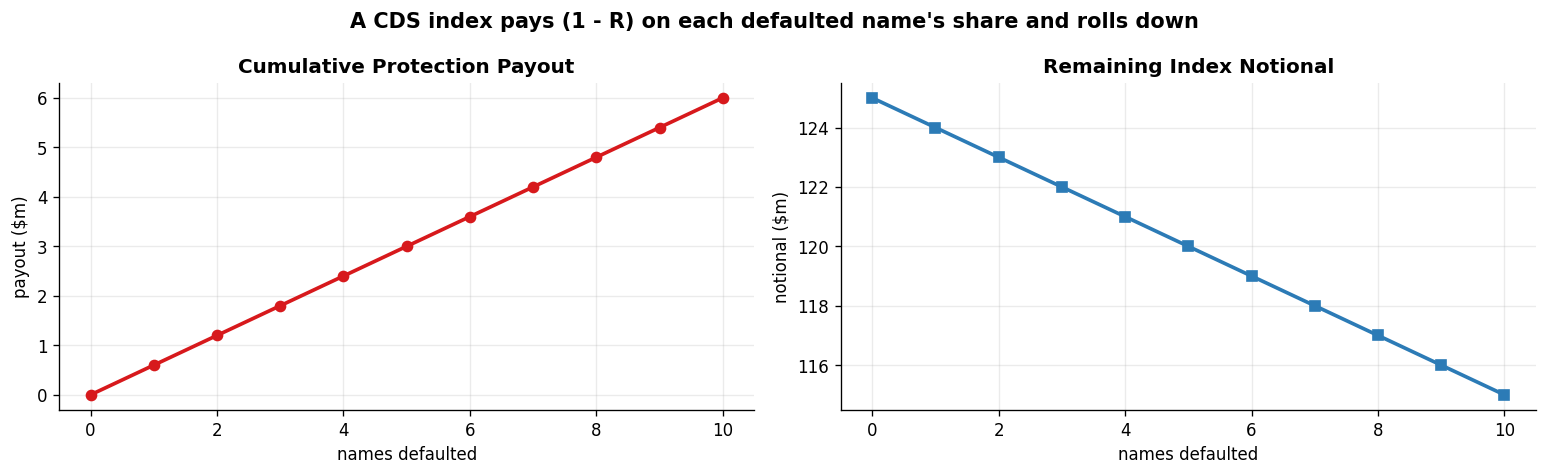


Basis: index quoted 120 bps vs average single-name 125 bps -> basis -5 bps.
Arbitrageurs trade the index against the cost of all 125 single-name CDS to keep the two aligned;
that index-vs-intrinsic basis is a classic relative-value credit trade.


In [14]:
# --- CDS index mechanics: CDX/iTraxx as a portfolio of single-name CDS ---
BLUE=globals().get("BLUE","#2E6E9E"); GREEN=globals().get("GREEN","#2ca25f")
RED=globals().get("RED","#c0392b"); GOLD=globals().get("GOLD","#d9a441")

N_NAMES = 125; INDEX_NOTIONAL = 125_000_000; COUPON = 0.01; R_IDX = 0.40
per_name = INDEX_NOTIONAL / N_NAMES
print(f"CDX IG-style index: {N_NAMES} equally-weighted names, ${INDEX_NOTIONAL:,.0f} protection bought, "
      f"coupon {COUPON:.0%}.")
print(f"Per-name notional = ${per_name:,.0f}; assumed auction recovery {R_IDX:.0%}.\n")

payout1 = per_name * (1 - R_IDX)
print(f"One name defaults -> protection payout = {per_name:,.0f} x (1 - {R_IDX:.0%}) = ${payout1:,.0f}")
print(f"Index factor drops to {(N_NAMES-1)/N_NAMES:.4f}; you keep paying {COUPON:.0%} on the "
      f"remaining ${INDEX_NOTIONAL-per_name:,.0f}.")

k = np.arange(0, 11)
cum_pay = k * payout1 / 1e6
running_notional = (INDEX_NOTIONAL - k*per_name) / 1e6
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(k, cum_pay, "o-", color=RED, lw=2.2)
ax[0].set_title("Cumulative Protection Payout", fontweight="bold")
ax[0].set_xlabel("names defaulted"); ax[0].set_ylabel("payout ($m)"); ax[0].grid(alpha=0.25)
ax[1].plot(k, running_notional, "s-", color=BLUE, lw=2.2)
ax[1].set_title("Remaining Index Notional", fontweight="bold")
ax[1].set_xlabel("names defaulted"); ax[1].set_ylabel("notional ($m)"); ax[1].grid(alpha=0.25)
for a in ax:
    for s in ["top", "right"]: a.spines[s].set_visible(False)
plt.suptitle("A CDS index pays (1 - R) on each defaulted name's share and rolls down",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

# index vs intrinsic (the basis)
avg_single = 0.0125           # illustrative average single-name spread (125 bps)
index_quote = 0.0120          # index trades a touch tighter (more liquid)
basis_bps = (index_quote - avg_single) * 1e4
print(f"\nBasis: index quoted {index_quote*1e4:.0f} bps vs average single-name {avg_single*1e4:.0f} bps "
      f"-> basis {basis_bps:+.0f} bps.")
print("Arbitrageurs trade the index against the cost of all 125 single-name CDS to keep the two aligned;")
print("that index-vs-intrinsic basis is a classic relative-value credit trade.")

## 4. One-Factor Gaussian Copula & Portfolio Credit Risk

**The Li (2000) Gaussian Copula Model.** Every obligor's *normalised asset value* is driven by a
common market factor $M$ and an idiosyncratic shock $Z_i$:

$$A_i = \sqrt{\rho}\,M + \sqrt{1-\rho}\,Z_i, \quad M, Z_i \overset{\text{iid}}{\sim} N(0,1)$$

Obligor $i$ defaults when $A_i < \Phi^{-1}(PD)$ (the default threshold). The asset correlation $\rho$
captures how much obligors move together.

**Conditional PD** given market factor $M$:

$$\text{PD}(M) = \Phi\!\left(\frac{\Phi^{-1}(PD) - \sqrt{\rho}\,M}{\sqrt{1-\rho}}\right)$$

**Monte-Carlo algorithm:**
1. Draw $M \sim N(0,1)$ for each scenario.
2. For each obligor, draw $Z_i \sim N(0,1)$ and compute $A_i$.
3. Default if $A_i < \Phi^{-1}(PD)$; portfolio loss = (number of defaults / N) times LGD.
4. Repeat for many scenarios to build the loss distribution.

In [15]:
# --- One-factor Gaussian copula simulation ---
np.random.seed(42)

N_OBLIGORS = 100    # homogeneous pool
PD_BASE    = 0.03   # 3% annual PD
LGD_BASE   = 0.45   # 45% LGD
RHO_BASE   = 0.15   # 15% asset correlation
N_SIM      = 200_000
CONF_LEVEL = 0.99   # Credit VaR confidence level

def simulate_portfolio_loss(N, PD, LGD, rho, n_sim, seed=42):
    """One-factor Gaussian copula loss simulation."""
    rng = np.random.default_rng(seed)
    threshold = norm.ppf(PD)          # Φ⁻¹(PD)
    M = rng.standard_normal(n_sim)    # systematic factor

    # Conditional default boundary for each scenario
    cond_boundary = (threshold - np.sqrt(rho) * M) / np.sqrt(1 - rho)

    # For each scenario, count defaults via idiosyncratic shocks
    # Memory-efficient: process in batches
    losses = np.zeros(n_sim)
    batch_size = 2000
    for start in range(0, n_sim, batch_size):
        end  = min(start + batch_size, n_sim)
        Z    = rng.standard_normal((end - start, N))          # idiosyncratic
        A    = np.sqrt(rho) * M[start:end, None] + np.sqrt(1 - rho) * Z
        defs = (A < threshold).sum(axis=1)
        losses[start:end] = defs / N * LGD
    return losses


print(f"Simulating {N_SIM:,} scenarios: N={N_OBLIGORS}, PD={PD_BASE:.0%}, "
      f"LGD={LGD_BASE:.0%}, ρ={RHO_BASE}…")
losses_base = simulate_portfolio_loss(N_OBLIGORS, PD_BASE, LGD_BASE, RHO_BASE, N_SIM)
print("Done.")

EL_base     = losses_base.mean() * 100
VaR99_base  = np.percentile(losses_base, 99)   * 100
VaR999_base = np.percentile(losses_base, 99.9) * 100
ES99_base   = losses_base[losses_base >= np.percentile(losses_base, 99)].mean() * 100
UL_base     = losses_base.std() * 100
Credit_VaR  = VaR99_base - EL_base

print(f"\n{'Metric':<30s} {'Value':>10s}  {'Theory':>10s}")
print(f"{'-'*52}")
print(f"{'Expected Loss (EL)':<30s} {EL_base:>10.3f}%  {PD_BASE*LGD_BASE*100:>10.3f}%")
print(f"{'Unexpected Loss (UL = 1σ)':<30s} {UL_base:>10.3f}%")
print(f"{'99% VaR':<30s} {VaR99_base:>10.3f}%")
print(f"{'99.9% VaR (Basel floor)':<30s} {VaR999_base:>10.3f}%")
print(f"{'99% ES':<30s} {ES99_base:>10.3f}%")
print(f"{'Credit VaR (99% VaR − EL)':<30s} {Credit_VaR:>10.3f}%")


Simulating 200,000 scenarios: N=100, PD=3%, LGD=45%, ρ=0.15…


Done.

Metric                              Value      Theory
----------------------------------------------------
Expected Loss (EL)                  1.351%       1.350%
Unexpected Loss (UL = 1σ)           1.544%
99% VaR                             7.200%
99.9% VaR (Basel floor)            11.250%
99% ES                              8.758%
Credit VaR (99% VaR − EL)           5.849%


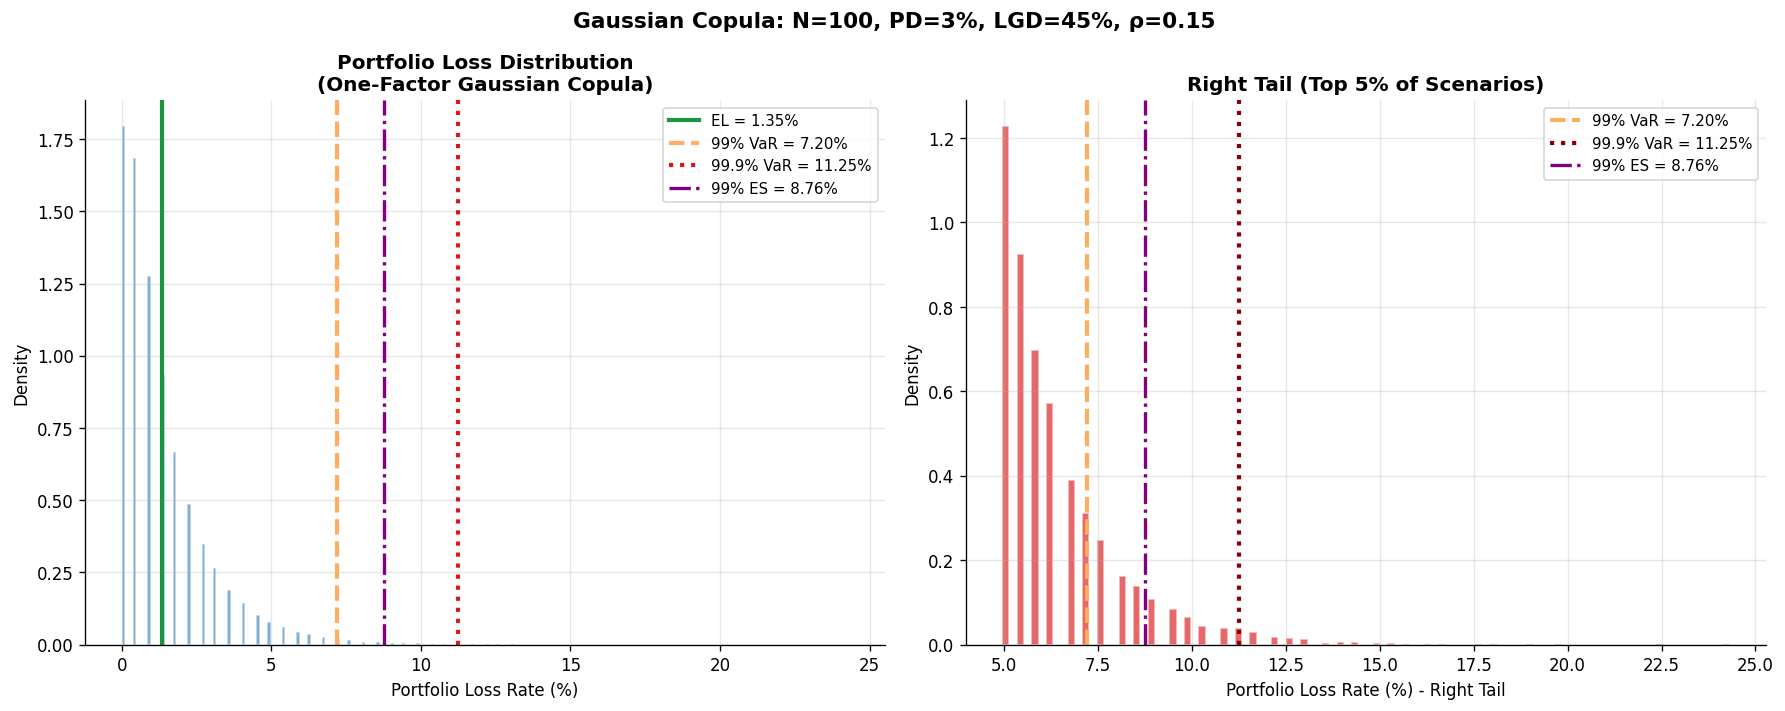

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Full loss distribution
axes[0].hist(losses_base * 100, bins=200, density=True,
             color=BLUE, alpha=0.60, edgecolor='white', lw=0.3)
axes[0].axvline(EL_base,     color=GREEN,    lw=2.5, ls='-',  label=f'EL = {EL_base:.2f}%')
axes[0].axvline(VaR99_base,  color=GOLD,     lw=2.5, ls='--', label=f'99% VaR = {VaR99_base:.2f}%')
axes[0].axvline(VaR999_base, color=RED,      lw=2.5, ls=':',  label=f'99.9% VaR = {VaR999_base:.2f}%')
axes[0].axvline(ES99_base,   color='purple', lw=2.0, ls='-.', label=f'99% ES = {ES99_base:.2f}%')
axes[0].set_xlabel('Portfolio Loss Rate (%)')
axes[0].set_ylabel('Density')
axes[0].set_title('Portfolio Loss Distribution\n(One-Factor Gaussian Copula)', fontweight='bold')
axes[0].legend(fontsize=9)

# Right tail (top 5%)
tail_cut  = np.percentile(losses_base, 95)
tail_loss = losses_base[losses_base > tail_cut] * 100
axes[1].hist(tail_loss, bins=100, density=True, color=RED, alpha=0.65, edgecolor='white')
axes[1].axvline(VaR99_base,  color=GOLD,   lw=2.5, ls='--', label=f'99% VaR = {VaR99_base:.2f}%')
axes[1].axvline(VaR999_base, color='darkred', lw=2.5, ls=':', label=f'99.9% VaR = {VaR999_base:.2f}%')
axes[1].axvline(ES99_base,   color='purple', lw=2.0, ls='-.',label=f'99% ES = {ES99_base:.2f}%')
axes[1].set_xlabel('Portfolio Loss Rate (%) - Right Tail')
axes[1].set_ylabel('Density')
axes[1].set_title('Right Tail (Top 5% of Scenarios)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(
    f'Gaussian Copula: N={N_OBLIGORS}, PD={PD_BASE:.0%}, LGD={LGD_BASE:.0%}, ρ={RHO_BASE}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Tail Dependence: Effect of Correlation ρ

<div style="background:#fef3cd; border-left: 5px solid #FDAE61; padding: 12px 16px; border-radius: 5px;">
<b style="color:#7a4100;">Key Insight</b><br>
Expected loss (EL = PD × LGD) is <em>independent of ρ</em>. However, higher correlation 
makes the right tail much fatter. More scenarios land near either 0% loss or full loss.
This is exactly what makes CDO senior tranches so sensitive to ρ assumptions.
</div>


Running correlation sweep…
  ρ=0.03: EL=1.350%  99% VaR=4.050%  99.9% VaR=5.400%
  ρ=0.10: EL=1.353%  99% VaR=5.850%  99.9% VaR=8.550%
  ρ=0.20: EL=1.354%  99% VaR=8.100%  99.9% VaR=13.500%


  ρ=0.35: EL=1.351%  99% VaR=12.600%  99.9% VaR=22.500%
  ρ=0.50: EL=1.350%  99% VaR=17.100%  99.9% VaR=30.600%


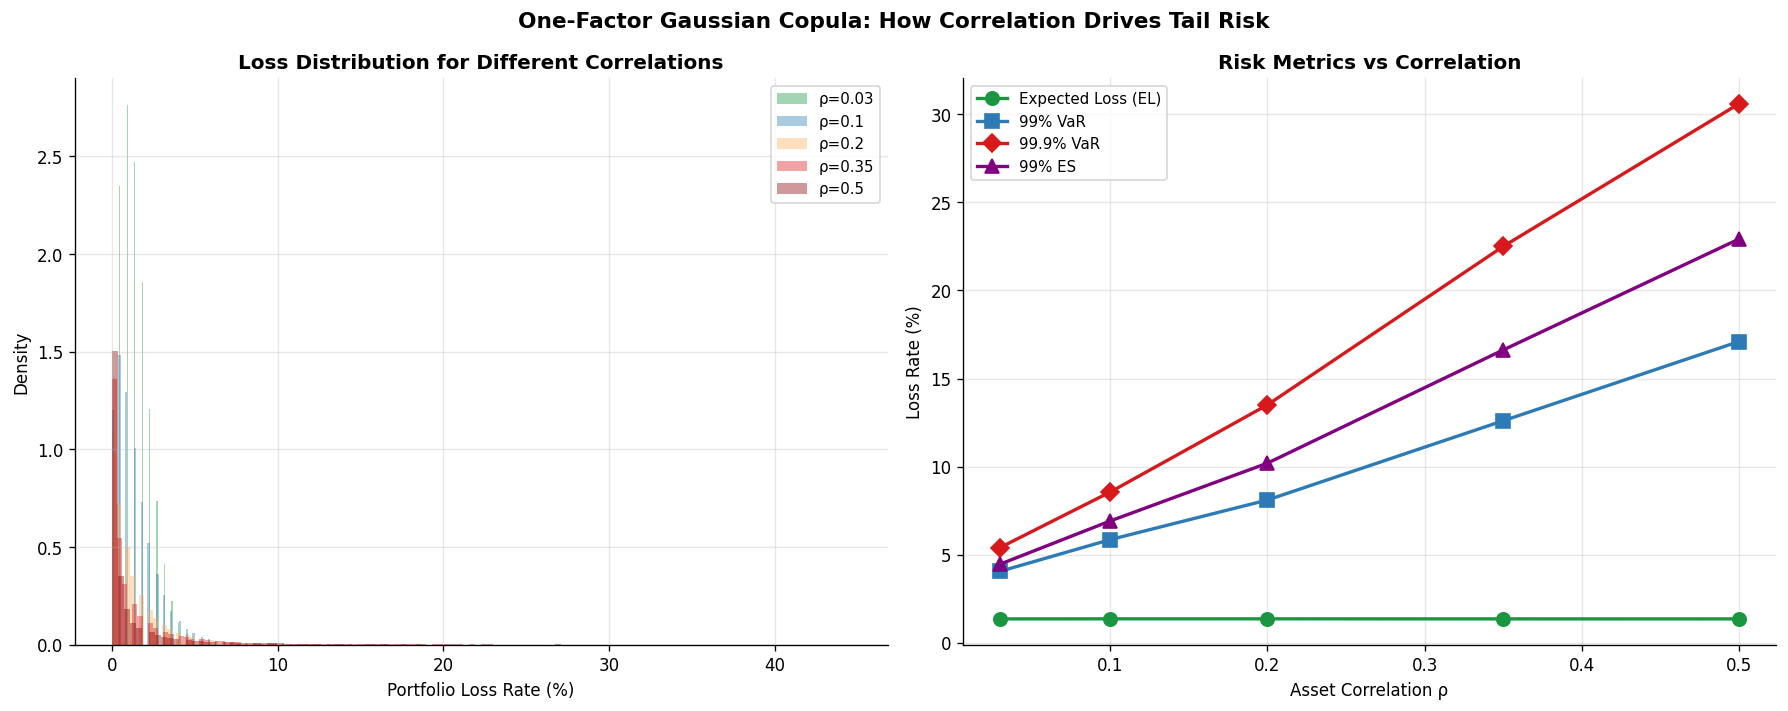


Key: EL stays flat; 99.9% VaR rises from 5.40% at ρ=0.03 to 30.60% at ρ=0.5.


In [17]:
np.random.seed(42)
rho_values  = [0.03, 0.10, 0.20, 0.35, 0.50]
colors_rho  = [GREEN, BLUE, GOLD, RED, '#8B0000']
N_SIM_RHO   = 100_000

results_rho = []
print("Running correlation sweep…")
for rho in rho_values:
    sim = simulate_portfolio_loss(N_OBLIGORS, PD_BASE, LGD_BASE, rho, N_SIM_RHO,
                                  seed=int(rho * 10000))
    results_rho.append({
        'rho': rho,
        'sim': sim,
        'EL':    sim.mean() * 100,
        'VaR99': np.percentile(sim, 99) * 100,
        'VaR999':np.percentile(sim, 99.9) * 100,
        'ES99':  sim[sim >= np.percentile(sim, 99)].mean() * 100,
    })
    print(f"  ρ={rho:.2f}: EL={results_rho[-1]['EL']:.3f}%  "
          f"99% VaR={results_rho[-1]['VaR99']:.3f}%  "
          f"99.9% VaR={results_rho[-1]['VaR999']:.3f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Loss distributions across ρ
for r_info, col in zip(results_rho, colors_rho):
    axes[0].hist(r_info['sim'] * 100, bins=120, density=True,
                 alpha=0.40, color=col, label=f"ρ={r_info['rho']}")
axes[0].set_xlabel('Portfolio Loss Rate (%)')
axes[0].set_ylabel('Density')
axes[0].set_title('Loss Distribution for Different Correlations', fontweight='bold')
axes[0].legend(fontsize=9)

# Risk metrics vs ρ
rho_axis = [r['rho']    for r in results_rho]
el_axis  = [r['EL']     for r in results_rho]
v99_axis = [r['VaR99']  for r in results_rho]
v999_ax  = [r['VaR999'] for r in results_rho]
es99_ax  = [r['ES99']   for r in results_rho]

axes[1].plot(rho_axis, el_axis,  'o-', color=GREEN,    lw=2, ms=8, label='Expected Loss (EL)')
axes[1].plot(rho_axis, v99_axis, 's-', color=BLUE,     lw=2, ms=8, label='99% VaR')
axes[1].plot(rho_axis, v999_ax,  'D-', color=RED,      lw=2, ms=8, label='99.9% VaR')
axes[1].plot(rho_axis, es99_ax,  '^-', color='purple', lw=2, ms=8, label='99% ES')
axes[1].set_xlabel('Asset Correlation ρ')
axes[1].set_ylabel('Loss Rate (%)')
axes[1].set_title('Risk Metrics vs Correlation', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('One-Factor Gaussian Copula: How Correlation Drives Tail Risk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey: EL stays flat; 99.9% VaR rises from "
      f"{results_rho[0]['VaR999']:.2f}% at ρ={results_rho[0]['rho']} to "
      f"{results_rho[-1]['VaR999']:.2f}% at ρ={results_rho[-1]['rho']}.")


## 6. Vasicek Large-Pool Analytical Formula

In the limit $N \to \infty$ (large homogeneous pool), the portfolio loss rate has an 
analytical distribution due to **Vasicek (2002)**:

$$F_L(x) = \Phi\!\left(\frac{\sqrt{1-\rho}\,\Phi^{-1}(x/\text{LGD}) - \Phi^{-1}(PD)}{\sqrt{\rho}}\right)$$

This is the backbone of the **Basel II/III IRB formula** for capital requirements.
The Monte Carlo simulation should converge to this as $N \to \infty$.


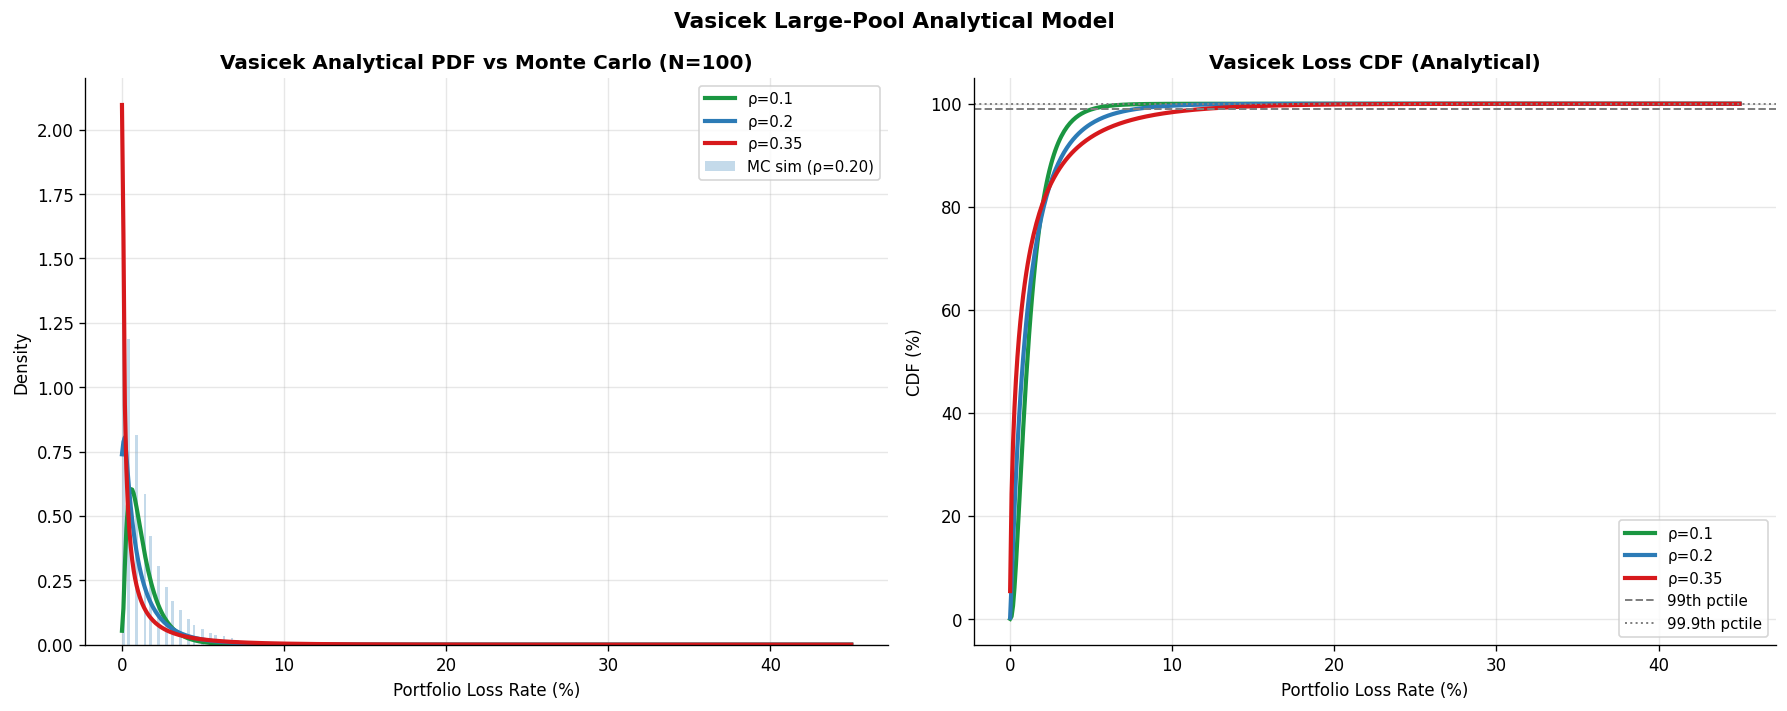

Vasicek analytical VaR vs Monte Carlo  (PD=3%, LGD=45%)
     ρ |   Analytical 99% VaR |   MC 99% VaR (N=100)
  0.03 |                3.003% |                4.050%
  0.10 |                5.117% |                5.850%
  0.20 |                7.817% |                8.100%
  0.35 |               11.958% |               12.600%
  0.50 |               16.622% |               17.100%


In [18]:
def vasicek_cdf(x, PD, LGD, rho):
    """Vasicek large-pool loss CDF at loss rate x."""
    if x <= 0:   return 0.0
    if x >= LGD: return 1.0
    num = np.sqrt(1 - rho) * norm.ppf(x / LGD) - norm.ppf(PD)
    return norm.cdf(num / np.sqrt(rho))

def vasicek_var(conf, PD, LGD, rho):
    """Vasicek analytical VaR at confidence level conf."""
    num = norm.ppf(PD) + np.sqrt(rho) * norm.ppf(conf)
    cond_pd = norm.cdf(num / np.sqrt(1 - rho))
    return cond_pd * LGD


x_grid = np.linspace(0.0001, LGD_BASE - 0.0001, 500)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for rho, col in zip([0.10, 0.20, 0.35], [GREEN, BLUE, RED]):
    cdf_vals = np.array([vasicek_cdf(x, PD_BASE, LGD_BASE, rho) for x in x_grid])
    pdf_vals = np.gradient(cdf_vals, x_grid)
    pdf_vals = np.clip(pdf_vals, 0, None)
    axes[0].plot(x_grid * 100, pdf_vals / 100, color=col, lw=2.5, label=f'ρ={rho}')
    axes[1].plot(x_grid * 100, cdf_vals * 100, color=col, lw=2.5, label=f'ρ={rho}')

# Overlay Monte Carlo histogram for ρ=0.20
sim_020 = simulate_portfolio_loss(N_OBLIGORS, PD_BASE, LGD_BASE, 0.20, N_SIM_RHO, seed=99)
axes[0].hist(sim_020 * 100, bins=150, density=True,
             alpha=0.28, color=BLUE, label='MC sim (ρ=0.20)')

axes[0].set_xlabel('Portfolio Loss Rate (%)')
axes[0].set_ylabel('Density')
axes[0].set_title('Vasicek Analytical PDF vs Monte Carlo (N=100)', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].axhline(99.0,   color='grey', ls='--', lw=1.2, label='99th pctile')
axes[1].axhline(99.9,   color='grey', ls=':',  lw=1.2, label='99.9th pctile')
axes[1].set_xlabel('Portfolio Loss Rate (%)')
axes[1].set_ylabel('CDF (%)')
axes[1].set_title('Vasicek Loss CDF (Analytical)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Vasicek Large-Pool Analytical Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Analytical VaR comparison
print(f"Vasicek analytical VaR vs Monte Carlo  (PD={PD_BASE:.0%}, LGD={LGD_BASE:.0%})")
print(f"{'ρ':>6s} | {'Analytical 99% VaR':>20s} | {'MC 99% VaR (N=100)':>20s}")
for r_info, col in zip(results_rho, colors_rho):
    rho = r_info['rho']
    analytical = vasicek_var(0.99, PD_BASE, LGD_BASE, rho) * 100
    mc_val     = r_info['VaR99']
    print(f"{rho:>6.2f} | {analytical:>20.3f}% | {mc_val:>20.3f}%")


## 7. Tail Dependence & the 2008 CDO Lesson

<div style="background:#fde8e8; border-left: 5px solid #D7191C; padding: 14px 18px; border-radius: 5px;">
<b style="color:#8b0000;">&#9888; Crisis Alert: The Gaussian Copula and 2008</b><br><br>
CDO senior tranches (rated AAA) promised to pay only when cumulative losses exceeded 
a high attachment point. Their value was very sensitive to the assumed asset 
correlation ρ. Yet in 2006 to 2007, banks and rating agencies kept 
<b>under-estimating ρ</b>, treating mortgage pools as nearly independent.
<ul>
<li><b>Low ρ assumption</b>: the right tail is thin → senior tranche looks safe.</li>
<li><b>Actual 2008 outcome (ρ → 1)</b>: the entire US housing market moves together 
(systematic factor dominates) → tail losses explode → senior tranches wiped out.</li>
<li>The Gaussian copula also lacks <em>tail dependence</em>: it under-prices 
joint extreme events compared with, say, a t-copula.</li>
</ul>
<b>Regulatory response:</b> Basel III FRTB replaces correlation assumptions with 
stressed calibrations; the SEC banned the use of mechanically obtained AAA ratings 
for structured products without supplementary stress tests.
</div>


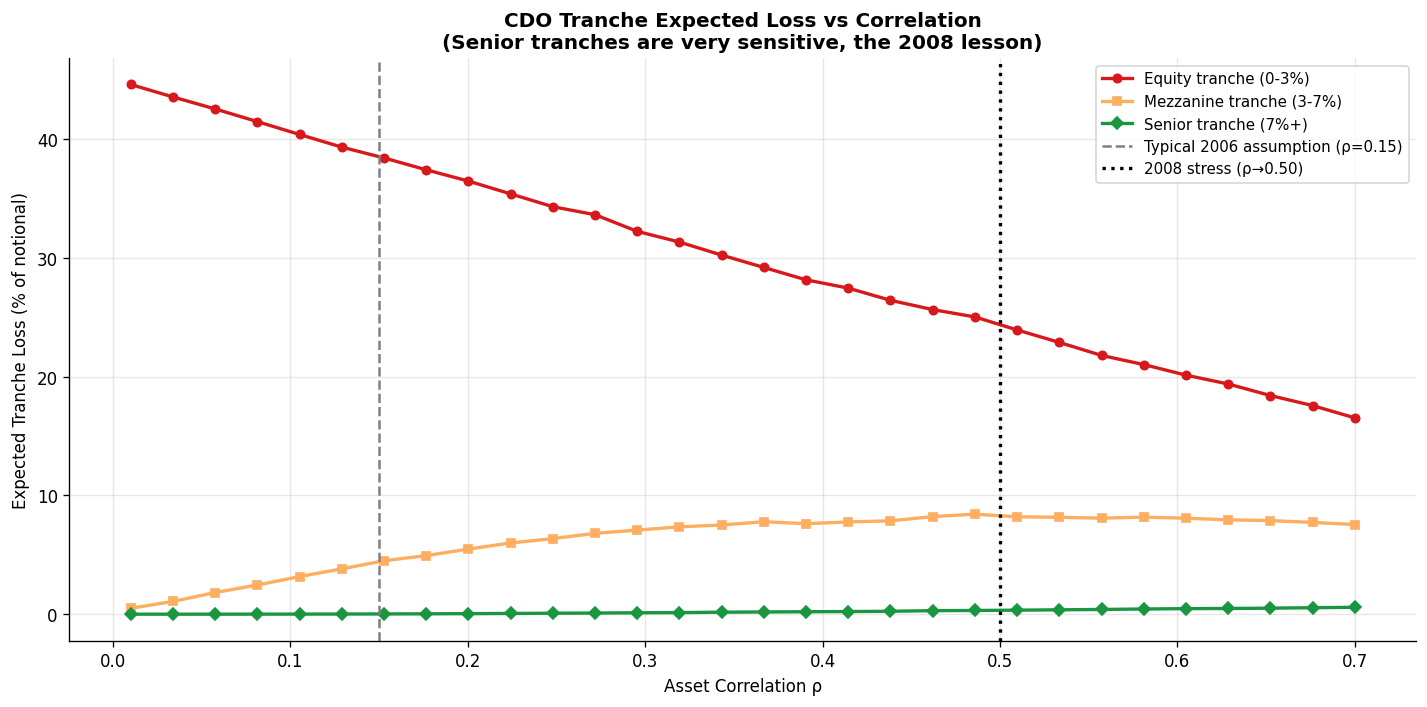

At ρ=0.15 (pre-crisis assumption):
  Equity tranche loss: 38.39%
  Mezzanine loss:      4.50%
  Senior tranche loss: 0.02%  ← appeared 'safe'

At ρ=0.50 (stress / 2008 outcome):
  Equity tranche loss: 23.92%
  Mezzanine loss:      8.19%
  Senior tranche loss: 0.34%  ← catastrophic


In [19]:
# --- Illustrate the CDO tranche sensitivity to ρ ---
np.random.seed(42)

ATTACH_JUNIOR  = 0.00   # 0-3% equity tranche
DETACH_JUNIOR  = 0.03
ATTACH_MEZZANINE = 0.03
DETACH_MEZZANINE = 0.07
ATTACH_SENIOR  = 0.07   # 7%+ senior tranche
DETACH_SENIOR  = 1.00

def tranche_loss(portfolio_losses, attach, detach):
    """Tranche expected loss fraction."""
    notional = detach - attach
    t_losses = np.clip(portfolio_losses - attach, 0, notional)
    return t_losses.mean() / notional * 100  # % of tranche notional

rho_sweep  = np.linspace(0.01, 0.70, 30)
el_junior  = []
el_mezz    = []
el_senior  = []

for rho in rho_sweep:
    sim = simulate_portfolio_loss(N_OBLIGORS, PD_BASE, LGD_BASE, rho, 50_000,
                                  seed=int(rho * 1e4))
    el_junior.append(tranche_loss(sim, ATTACH_JUNIOR,    DETACH_JUNIOR))
    el_mezz.append(  tranche_loss(sim, ATTACH_MEZZANINE, DETACH_MEZZANINE))
    el_senior.append(tranche_loss(sim, ATTACH_SENIOR,    DETACH_SENIOR))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rho_sweep, el_junior, 'o-', color=RED,   lw=2, ms=5, label='Equity tranche (0-3%)')
ax.plot(rho_sweep, el_mezz,   's-', color=GOLD,  lw=2, ms=5, label='Mezzanine tranche (3-7%)')
ax.plot(rho_sweep, el_senior, 'D-', color=GREEN, lw=2, ms=5, label='Senior tranche (7%+)')
ax.axvline(0.15, color='grey', ls='--', lw=1.5, label='Typical 2006 assumption (ρ=0.15)')
ax.axvline(0.50, color='black', ls=':', lw=2.0, label='2008 stress (ρ→0.50)')
ax.set_xlabel('Asset Correlation ρ')
ax.set_ylabel('Expected Tranche Loss (% of notional)')
ax.set_title('CDO Tranche Expected Loss vs Correlation\n'
             '(Senior tranches are very sensitive, the 2008 lesson)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("At ρ=0.15 (pre-crisis assumption):")
idx_15 = np.argmin(np.abs(rho_sweep - 0.15))
print(f"  Equity tranche loss: {el_junior[idx_15]:.2f}%")
print(f"  Mezzanine loss:      {el_mezz[idx_15]:.2f}%")
print(f"  Senior tranche loss: {el_senior[idx_15]:.2f}%  ← appeared 'safe'")

print("\nAt ρ=0.50 (stress / 2008 outcome):")
idx_50 = np.argmin(np.abs(rho_sweep - 0.50))
print(f"  Equity tranche loss: {el_junior[idx_50]:.2f}%")
print(f"  Mezzanine loss:      {el_mezz[idx_50]:.2f}%")
print(f"  Senior tranche loss: {el_senior[idx_50]:.2f}%  ← catastrophic")


## 8. CreditMetrics: Portfolio Risk from Rating Migration

The Gaussian copula above is a **default-mode** model: an obligor either survives or defaults.
J.P. Morgan's **CreditMetrics** (1997) does more: it is a **mark-to-market** model. Over a one-year
horizon each bond can migrate to *any* rating, and we revalue it at that rating's credit spread.
Losses come not only from default but from **downgrades** (spread widening), and gains from upgrades.

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:13px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:6px;">Built directly on Session 5's real transition matrix</div>
<div style="color:#B8D4E8;line-height:1.7;">
<strong>1.</strong> Take the starting rating's row of the <em>real S&amp;P 1981-2024 transition matrix</em>
(the not-rated column is dropped and the row renormalised).<br>
<strong>2.</strong> Revalue the bond in each of the 8 end-states by discounting its cashflows at the
risk-free rate plus that rating's <em>real</em> credit spread; a defaulted bond is worth its recovery.<br>
<strong>3.</strong> The transition probabilities give the full one-year <em>value distribution</em>:
its mean, volatility, and percentile-based <strong>Credit VaR</strong>.<br>
Correlated migrations across many bonds are then driven by the same one-factor Gaussian copula.</div>
</div>

CreditMetrics one-year revaluation of a BBB bond (4% coupon, 4y remaining, recovery 40%)
End rating   Prob %     Value
AAA            0.00    97.382
AA             0.07    96.833
A              3.23    96.505
BBB           92.62    95.348
BB             3.40    93.111
B              0.42    88.733
CCC/C          0.10    68.726
D              0.15    40.000

Mean value = 95.175   Std = 2.366   99% Credit VaR = 2.063 (per 100 face)


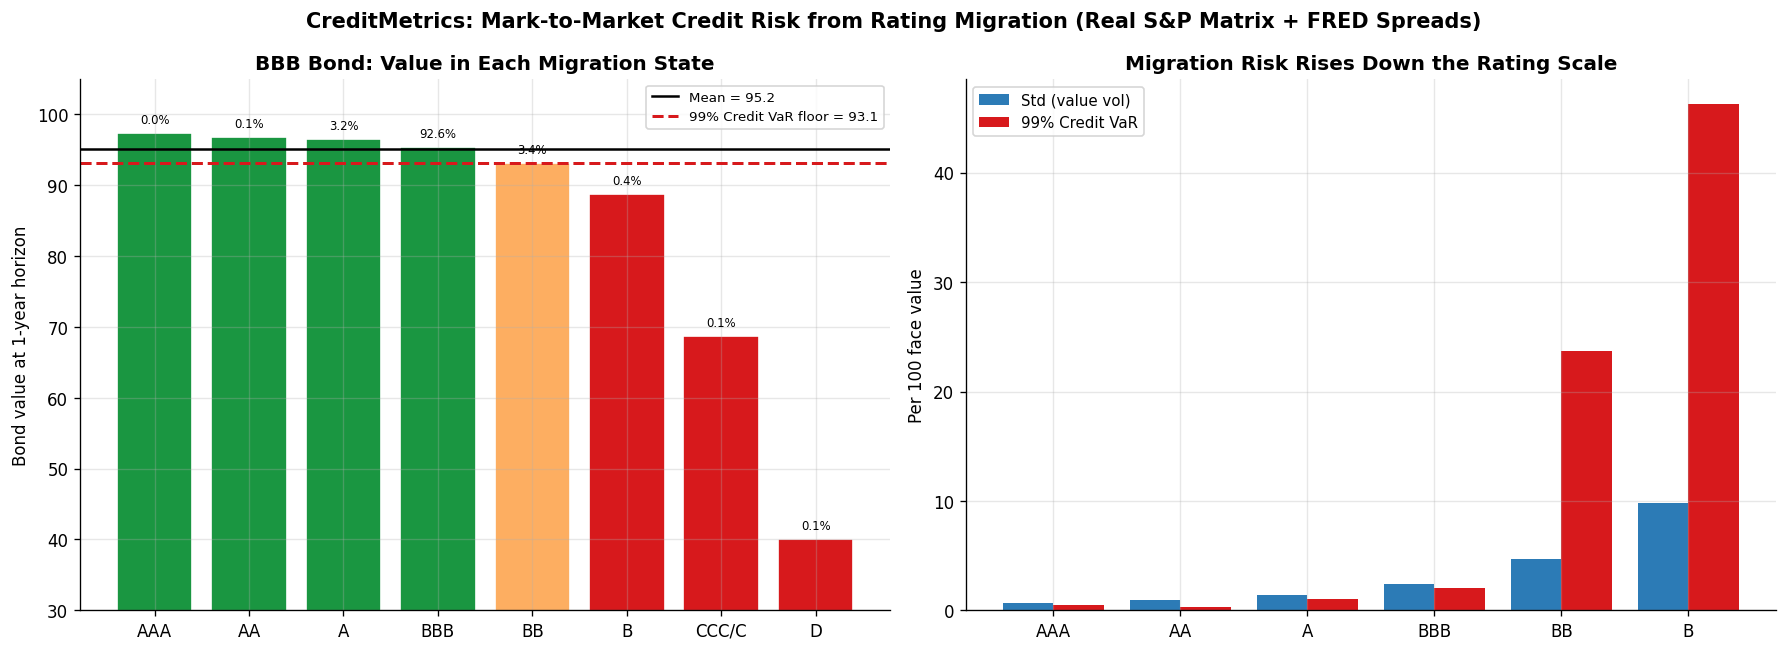

In [20]:
# --- CreditMetrics: one-year value distribution of a single bond ---
cm_trans = pd.read_csv(os.path.join(DATA_DIR, "sp_transition_1981_2024.csv"), index_col=0)
_cs = fred_spreads().dropna(how="all").iloc[-1]
cm_col = {"AAA":"AAA","AA":"AA","A":"A_","BBB":"BBB","BB":"BB","B":"B","CCC/C":"CCC"}
cm_spread = {r: float(_cs[c])/100 for r,c in cm_col.items()}     # decimal spread by rating
cm_states = ["AAA","AA","A","BBB","BB","B","CCC/C","D"]
rf = fred_rf(4)          # risk-free = ~4y Treasury (FRED, interpolated between DGS3 and DGS5)
CM_REC, CM_RF, CM_C, CM_M = 0.40, rf, 4.0, 4      # 40% recovery, 4% coupon, 4y remaining

def cm_value(spread, C=CM_C, F=100.0, M=CM_M, rf=CM_RF):
    t = np.arange(1, M+1)
    return (C*np.exp(-(rf+spread)*t)).sum() + F*np.exp(-(rf+spread)*M)
cm_vals = np.array([CM_REC*100 if r=="D" else cm_value(cm_spread[r]) for r in cm_states])

def creditmetrics_bond(start):
    row = cm_trans.loc[start, cm_states].values.astype(float); row = row/row.sum()
    EV  = (row*cm_vals).sum(); sd = np.sqrt((row*(cm_vals-EV)**2).sum())
    o = np.argsort(cm_vals); cp = np.cumsum(row[o]); vs = cm_vals[o]
    q1  = vs[np.searchsorted(cp, 0.01, side="left")]
    return row, EV, sd, EV-q1

START_RATING = "BBB"
row, EV, sd, cvar99 = creditmetrics_bond(START_RATING)
print(f"CreditMetrics one-year revaluation of a {START_RATING} bond "
      f"(4% coupon, {CM_M}y remaining, recovery {CM_REC:.0%})")
print(f"{'End rating':10s} {'Prob %':>8s} {'Value':>9s}")
for r,p,v in zip(cm_states, row, cm_vals):
    print(f"{r:10s} {p*100:8.2f} {v:9.3f}")
print(f"\nMean value = {EV:.3f}   Std = {sd:.3f}   99% Credit VaR = {cvar99:.3f} (per 100 face)")

# Value distribution across starting ratings + the BBB bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
vcolors = [GREEN if v>=EV else (GOLD if v>=cm_vals[cm_states.index("BB")] else RED) for v in cm_vals]
axes[0].bar(cm_states, cm_vals, color=vcolors, edgecolor="white")
axes[0].axhline(EV, color="black", lw=1.5, ls="-", label=f"Mean = {EV:.1f}")
axes[0].axhline(EV-cvar99, color=RED, lw=1.8, ls="--", label=f"99% Credit VaR floor = {EV-cvar99:.1f}")
for i,(p,v) in enumerate(zip(row, cm_vals)):
    axes[0].text(i, v+1, f"{p*100:.1f}%", ha="center", va="bottom", fontsize=7)
axes[0].set_ylabel("Bond value at 1-year horizon"); axes[0].set_ylim(30, 105)
axes[0].set_title(f"{START_RATING} Bond: Value in Each Migration State", fontweight="bold")
axes[0].legend(fontsize=8)

tbl = []
for st in ["AAA","AA","A","BBB","BB","B"]:
    _, ev, s, cv = creditmetrics_bond(st); tbl.append((st, ev, s, cv))
sts=[t[0] for t in tbl]
axes[1].bar(np.arange(len(sts))-0.2, [t[2] for t in tbl], 0.4, color=BLUE, label="Std (value vol)")
axes[1].bar(np.arange(len(sts))+0.2, [t[3] for t in tbl], 0.4, color=RED,  label="99% Credit VaR")
axes[1].set_xticks(range(len(sts))); axes[1].set_xticklabels(sts)
axes[1].set_ylabel("Per 100 face value"); axes[1].set_title("Migration Risk Rises Down the Rating Scale", fontweight="bold")
axes[1].legend(fontsize=9)
plt.suptitle("CreditMetrics: Mark-to-Market Credit Risk from Rating Migration (Real S&P Matrix + FRED Spreads)",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

Portfolio of 50 BBB bonds, asset correlation rho=0.15
  Mean portfolio value      : 4,758.7  (par = 5,000)
  99%   Credit VaR (migration):   93.4
  99.9% Credit VaR (migration):  186.5
  99%   VaR (default-only)     :   60.0

Migration mode captures downgrade (spread) losses the default-only view misses:
  99% Credit VaR is 1.6x the default-only figure.


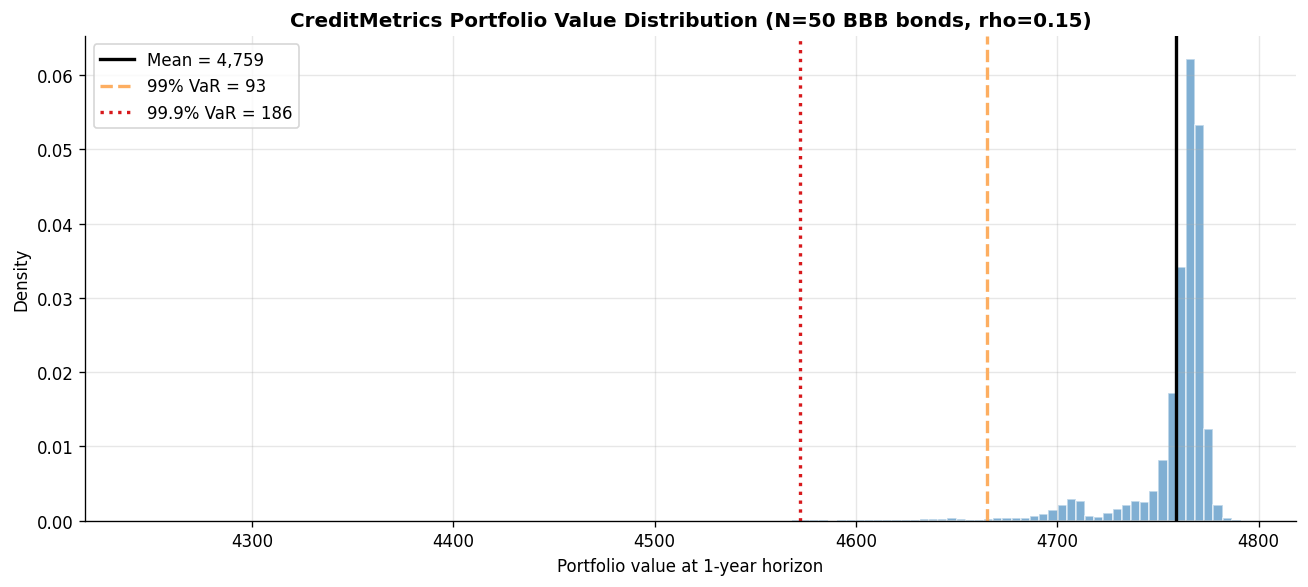

In [21]:
# --- CreditMetrics portfolio: correlated migrations via one-factor copula ---
def creditmetrics_portfolio(start="BBB", N=50, rho=0.15, nsim=100_000, seed=7):
    rng = np.random.default_rng(seed)
    row = cm_trans.loc[start, cm_states].values.astype(float); row = row/row.sum()
    asc_val = cm_vals[::-1]                       # ascending creditworthiness: D..AAA
    zthr = norm.ppf(np.clip(np.cumsum(row[::-1]), 1e-9, 1-1e-9))
    M = rng.standard_normal((nsim, 1)); Z = rng.standard_normal((nsim, N))
    A = np.sqrt(rho)*M + np.sqrt(1-rho)*Z         # latent asset returns
    idx = np.clip(np.searchsorted(zthr, A), 0, len(asc_val)-1)
    port = asc_val[idx].sum(axis=1)               # portfolio value per scenario
    # default-only benchmark: same latent variables, only default vs par
    ndef = (A < zthr[0]).sum(axis=1)
    loss_default_only = ndef * (100 - CM_REC*100)
    return port, loss_default_only

N_CM, RHO_CM = 50, 0.15
port, loss_do = creditmetrics_portfolio("BBB", N=N_CM, rho=RHO_CM)
EVp = port.mean()
cvar99_mig = EVp - np.percentile(port, 1)         # migration-mode credit VaR
cvar999_mig= EVp - np.percentile(port, 0.1)
var99_do   = np.percentile(loss_do, 99)           # default-only VaR (loss units)

print(f"Portfolio of {N_CM} BBB bonds, asset correlation rho={RHO_CM}")
print(f"  Mean portfolio value      : {EVp:,.1f}  (par = {N_CM*100:,})")
print(f"  99%   Credit VaR (migration): {cvar99_mig:6.1f}")
print(f"  99.9% Credit VaR (migration): {cvar999_mig:6.1f}")
print(f"  99%   VaR (default-only)     : {var99_do:6.1f}")
print(f"\nMigration mode captures downgrade (spread) losses the default-only view misses:")
print(f"  99% Credit VaR is {cvar99_mig/max(var99_do,1e-9):.1f}x the default-only figure.")

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(port, bins=120, density=True, color=BLUE, alpha=0.6, edgecolor="white", lw=0.3)
ax.axvline(EVp, color="black", lw=2, label=f"Mean = {EVp:,.0f}")
ax.axvline(EVp-cvar99_mig, color=GOLD, lw=2, ls="--", label=f"99% VaR = {cvar99_mig:.0f}")
ax.axvline(EVp-cvar999_mig, color=RED, lw=2, ls=":", label=f"99.9% VaR = {cvar999_mig:.0f}")
ax.set_xlabel("Portfolio value at 1-year horizon"); ax.set_ylabel("Density")
ax.set_title(f"CreditMetrics Portfolio Value Distribution (N={N_CM} BBB bonds, rho={RHO_CM})", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

## 9. CreditRisk+ : the Actuarial Alternative

Credit Suisse's **CreditRisk+** (1997) comes from insurance mathematics, not option pricing.
It never simulates asset values or migrations. It needs only each obligor's **PD** and
**exposure**. The number of defaults follows a **Poisson** distribution; correlation enters by
letting the *average default rate itself* be random (a **Gamma**-distributed systematic factor),
which fattens the tail exactly as asset correlation does in the copula.

<div style="border-left:5px solid #1A9641;background:#0A2A1A;padding:13px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#52C97A;font-weight:700;margin-bottom:6px;">Three models, one loss distribution</div>
<div style="color:#A8D8B0;line-height:1.7;">We run CreditRisk+ on the <em>same</em> pool as the Gaussian copula (Section 4) and put all three
99.9% VaRs side by side: <strong>copula</strong> (asset-value threshold), <strong>Vasicek</strong>
(its large-pool analytic limit), and <strong>CreditRisk+</strong> (actuarial). Gamma default-rate
volatility is the CreditRisk+ dial that plays the role of asset correlation. Turn it up and the
tail gets fatter. Here we set it so CreditRisk+ reproduces the copula's 99.9% VaR, showing the two
model families can be reconciled.</div>
</div>

Loss distribution comparison  (N=100, PD=3%, LGD=45%)
Model                             EL %   99% VaR  99.9% VaR
------------------------------------------------------------
Gaussian copula (Sec. 4)         1.351     7.200     11.250
Vasicek analytic                 1.350     6.478     10.309
CreditRisk+ (w=1.0)              1.355     7.200     10.800
CreditRisk+ (independent)        1.351     3.600      4.500


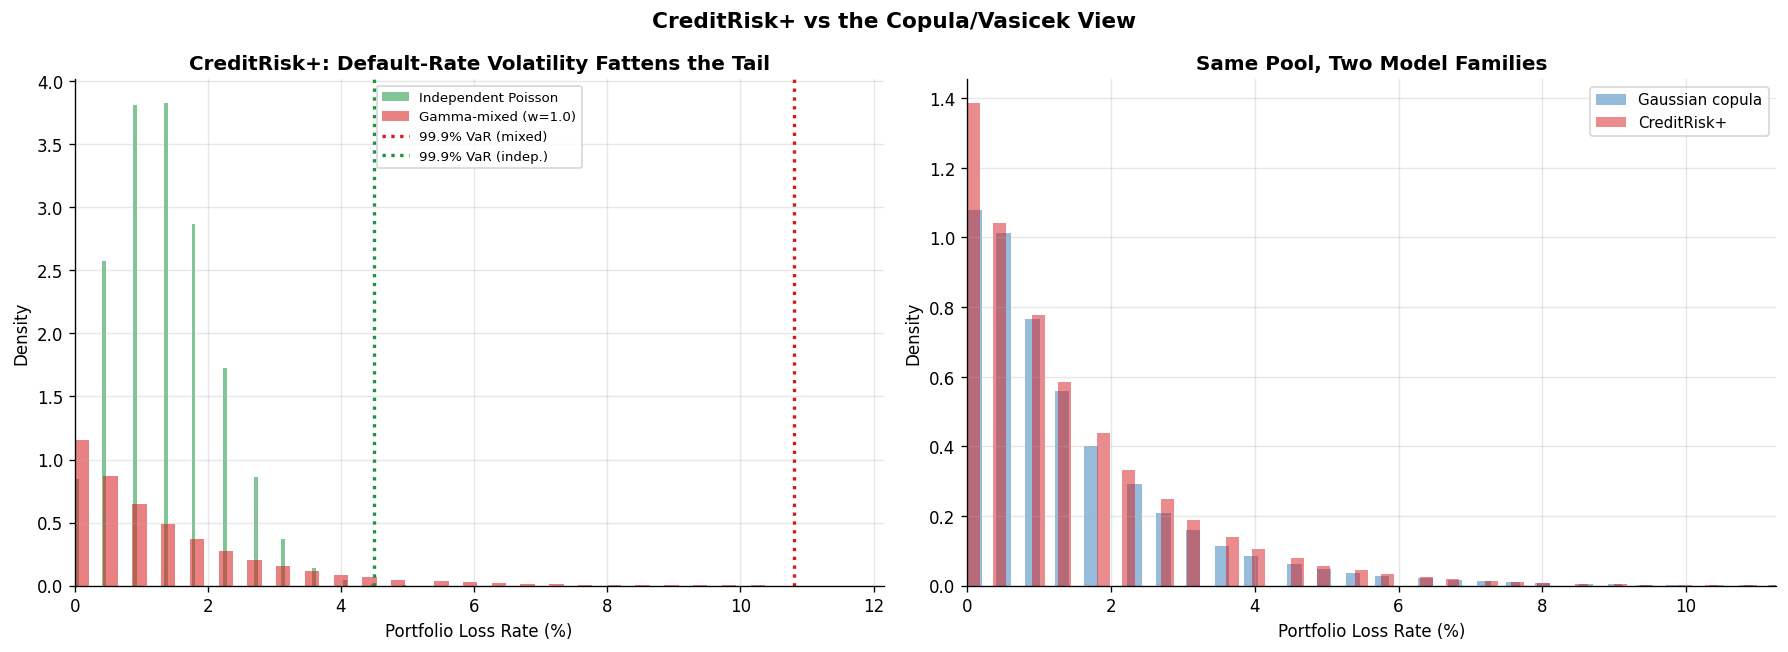


With default-rate volatility tuned to the copula's rho=0.15, all three 99.9% VaRs
nearly coincide: different mathematics (asset threshold, analytic limit, actuarial
mixing), one answer. Expected loss is trivial; the systematic factor owns the tail.


In [22]:
# --- CreditRisk+ : gamma-mixed Poisson on the same pool as Section 4 ---
def creditriskplus(N, PD, LGD, sigma_ratio, nsim=300_000, seed=11):
    """Loss-rate distribution. sigma_ratio = std/mean of the systematic default-rate factor."""
    rng = np.random.default_rng(seed)
    if sigma_ratio <= 0:
        ndef = rng.poisson(N*PD, nsim)
    else:
        k = 1.0/sigma_ratio**2                       # Gamma shape (mean 1)
        G = rng.gamma(k, 1.0/k, nsim)                # systematic factor, E[G]=1
        ndef = rng.poisson(np.clip(N*PD*G, 0, None))
    return np.minimum(ndef, N)/N*LGD                 # loss rate

W_CRP = 1.00   # default-rate volatility; ~matches the copula's rho=0.15 tail (see note)
loss_crp  = creditriskplus(N_OBLIGORS, PD_BASE, LGD_BASE, W_CRP)   * 100
loss_crp0 = creditriskplus(N_OBLIGORS, PD_BASE, LGD_BASE, 0.0)     * 100   # independent

def q(a, p): return np.percentile(a, p)
rows = [
    ("Gaussian copula (Sec. 4)", losses_base.mean()*100, q(losses_base*100,99), q(losses_base*100,99.9)),
    ("Vasicek analytic",         PD_BASE*LGD_BASE*100,
        vasicek_var(0.99, PD_BASE, LGD_BASE, RHO_BASE)*100,
        vasicek_var(0.999, PD_BASE, LGD_BASE, RHO_BASE)*100),
    (f"CreditRisk+ (w={W_CRP})",  loss_crp.mean(),  q(loss_crp,99),  q(loss_crp,99.9)),
    ("CreditRisk+ (independent)", loss_crp0.mean(), q(loss_crp0,99), q(loss_crp0,99.9)),
]
print(f"Loss distribution comparison  (N={N_OBLIGORS}, PD={PD_BASE:.0%}, LGD={LGD_BASE:.0%})")
print(f"{'Model':30s} {'EL %':>7s} {'99% VaR':>9s} {'99.9% VaR':>10s}")
print("-"*60)
for name, el, v99, v999 in rows:
    print(f"{name:30s} {el:7.3f} {v99:9.3f} {v999:10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].hist(loss_crp0, bins=100, density=True, alpha=0.55, color=GREEN, label="Independent Poisson")
axes[0].hist(loss_crp,  bins=100, density=True, alpha=0.55, color=RED,   label=f"Gamma-mixed (w={W_CRP})")
axes[0].axvline(q(loss_crp,99.9),  color=RED,   ls=":", lw=2, label="99.9% VaR (mixed)")
axes[0].axvline(q(loss_crp0,99.9), color=GREEN, ls=":", lw=2, label="99.9% VaR (indep.)")
axes[0].set_xlabel("Portfolio Loss Rate (%)"); axes[0].set_ylabel("Density")
axes[0].set_title("CreditRisk+: Default-Rate Volatility Fattens the Tail", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].set_xlim(0, max(q(loss_crp,99.95), q(losses_base*100,99.95)))

axes[1].hist(losses_base*100, bins=120, density=True, alpha=0.5, color=BLUE, label="Gaussian copula")
axes[1].hist(loss_crp,        bins=120, density=True, alpha=0.5, color=RED,  label="CreditRisk+")
axes[1].set_xlabel("Portfolio Loss Rate (%)"); axes[1].set_ylabel("Density")
axes[1].set_title("Same Pool, Two Model Families", fontweight="bold")
axes[1].legend(fontsize=9); axes[1].set_xlim(0, max(q(loss_crp,99.9), q(losses_base*100,99.9)))
plt.suptitle("CreditRisk+ vs the Copula/Vasicek View", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("\nWith default-rate volatility tuned to the copula's rho=0.15, all three 99.9% VaRs")
print("nearly coincide: different mathematics (asset threshold, analytic limit, actuarial")
print("mixing), one answer. Expected loss is trivial; the systematic factor owns the tail.")

## 10. Counterparty Credit Risk: CVA

Everything so far priced the risk that *borrowers* default. But a derivative (a swap, a forward)
also carries the risk that the **counterparty** defaults while the trade is in your favour. The
market price of that risk is the **Credit Valuation Adjustment** (CVA): the discount to a derivative's
risk-free value, and since Basel III a capital charge on its own. It is the reason banks built
CVA desks after 2008.

$$\text{CVA} = \text{LGD}\;\sum_{k} \underbrace{\text{EE}(t_k)}_{\text{expected exposure}}\;
\underbrace{\big[S(t_{k-1})-S(t_k)\big]}_{\text{default in }(t_{k-1},t_k]}\;\underbrace{\text{DF}(t_k)}_{\text{discount}}$$

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:13px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:6px;">Two ingredients, both already in hand</div>
<div style="color:#B8D4E8;line-height:1.7;">
<strong>Exposure</strong>: we simulate a 5-year payer interest-rate swap under a <strong>Vasicek
short-rate model</strong> and read off the <strong>expected exposure</strong> EE(t) = E[max(V(t),0)]
and <strong>potential future exposure</strong> PFE (a high quantile). The swap's exposure has the
classic <em>hump</em>: it grows as rates can drift, then falls to zero as payments run off.<br>
<strong>Default</strong>: the counterparty's survival curve S(t) comes straight from the
<strong>real hazard curve we bootstrapped</strong> in Section 3, and we then sweep CVA across the
<strong>real market credit curve</strong> (FRED OAS by rating). <strong>DVA</strong> (your own default,
using negative exposure) and <strong>wrong-way risk</strong> (exposure correlated with the
counterparty's default) are the two refinements a desk adds next.</div>
</div>

5y quarterly payer swap, par fixed rate K = 4.265%  (notional = 1)


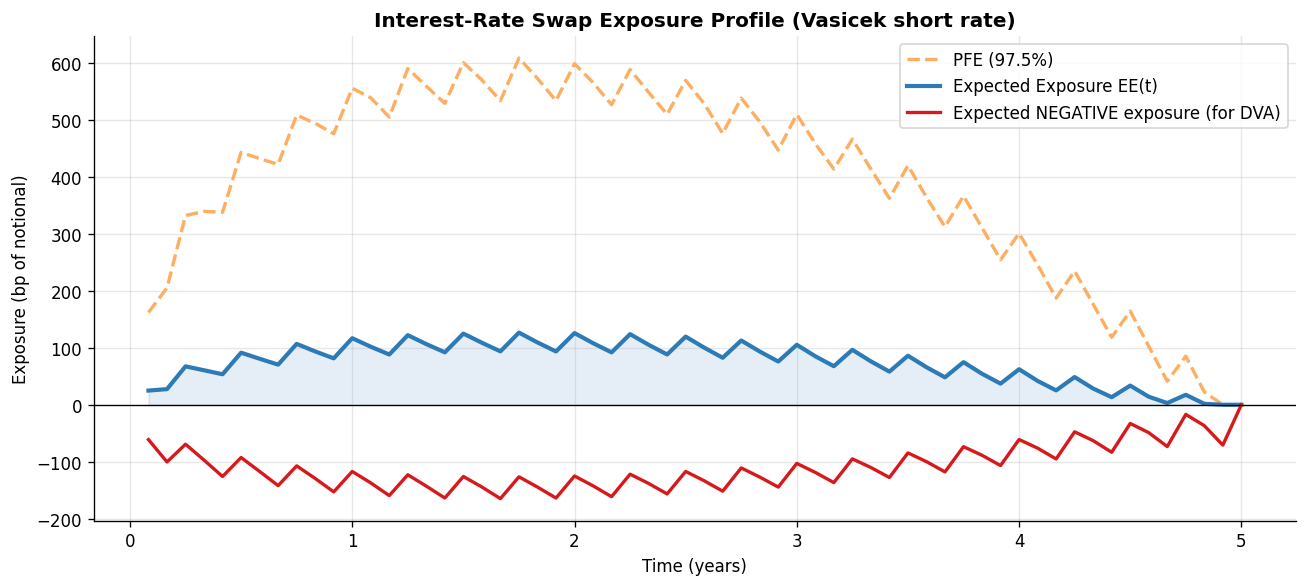

Peak EE = 126 bp at t = 1.75y | peak PFE = 608 bp
The hump: exposure builds as rates can wander, then falls as the swap runs off to zero.


In [23]:
# --- Exposure profile of a 5y payer interest-rate swap (Vasicek short rate) ---
rf = fred_rf(5)          # risk-free = 5y Treasury (FRED, DGS5) to match the 5-year swap
a_vas, b_vas, sig_vas, r0 = 0.10, rf, 0.01, rf   # mean-reversion, long-run, vol, r(0)
def _B(t,T): return (1-np.exp(-a_vas*(T-t)))/a_vas
def _A(t,T):
    Bt=_B(t,T)
    return np.exp((Bt-(T-t))*(a_vas*a_vas*b_vas-0.5*sig_vas**2)/a_vas**2 - sig_vas**2*Bt**2/(4*a_vas))
def _Pv(t, Ts, r):                       # zero-bond prices P(t,Ts) for a vector of short rates r
    r=np.atleast_1d(r); return _A(t,Ts)[None,:]*np.exp(-_B(t,Ts)[None,:]*r[:,None])

Tn, freq = 5.0, 4
tau  = 1/freq
pay  = np.arange(tau, Tn+1e-9, tau)      # swap payment dates
P0   = _Pv(0, pay, r0)[0]
K    = (1 - P0[-1]) / (tau * P0.sum())   # par fixed rate -> swap starts at zero value
print(f"5y quarterly payer swap, par fixed rate K = {K:.3%}  (notional = 1)")

rng = np.random.default_rng(7)
NPATH, dt = 20_000, 1/12
edates = np.arange(dt, Tn+1e-9, dt)
r = np.full(NPATH, r0); EE=[]; PFE=[]; ENE=[]
for t in edates:
    m = r*np.exp(-a_vas*dt) + b_vas*(1-np.exp(-a_vas*dt))
    v = sig_vas**2/(2*a_vas)*(1-np.exp(-2*a_vas*dt))
    r = m + np.sqrt(v)*rng.standard_normal(NPATH)
    rem = pay[pay > t+1e-9]
    if len(rem)==0:
        V = np.zeros(NPATH)
    else:
        Pm = _Pv(t, rem, r)
        V  = (1 - Pm[:,-1]) - K*tau*Pm.sum(axis=1)     # payer swap value
    EE.append(np.maximum(V,0).mean()); ENE.append(np.minimum(V,0).mean())
    PFE.append(np.percentile(np.maximum(V,0), 97.5))
EE, ENE, PFE = map(np.array,(EE,ENE,PFE))
DF = _Pv(0, edates, r0)[0]

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(edates, PFE*1e4, color=GOLD, lw=2, ls='--', label='PFE (97.5%)')
ax.plot(edates, EE*1e4,  color=BLUE, lw=2.5, label='Expected Exposure EE(t)')
ax.fill_between(edates, 0, EE*1e4, color=BLUE, alpha=0.12)
ax.plot(edates, ENE*1e4, color=RED,  lw=2, label='Expected NEGATIVE exposure (for DVA)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Time (years)'); ax.set_ylabel('Exposure (bp of notional)')
ax.set_title('Interest-Rate Swap Exposure Profile (Vasicek short rate)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Peak EE = {EE.max()*1e4:.0f} bp at t = {edates[EE.argmax()]:.2f}y | peak PFE = {PFE.max()*1e4:.0f} bp")
print("The hump: exposure builds as rates can wander, then falls as the swap runs off to zero.")

Counterparty = the bootstrapped IG credit curve (Section 3):
  CVA = 2.22 bp of notional  (risk-free swap value is ~0 at inception,
  so this is the credit charge the desk books against the trade).


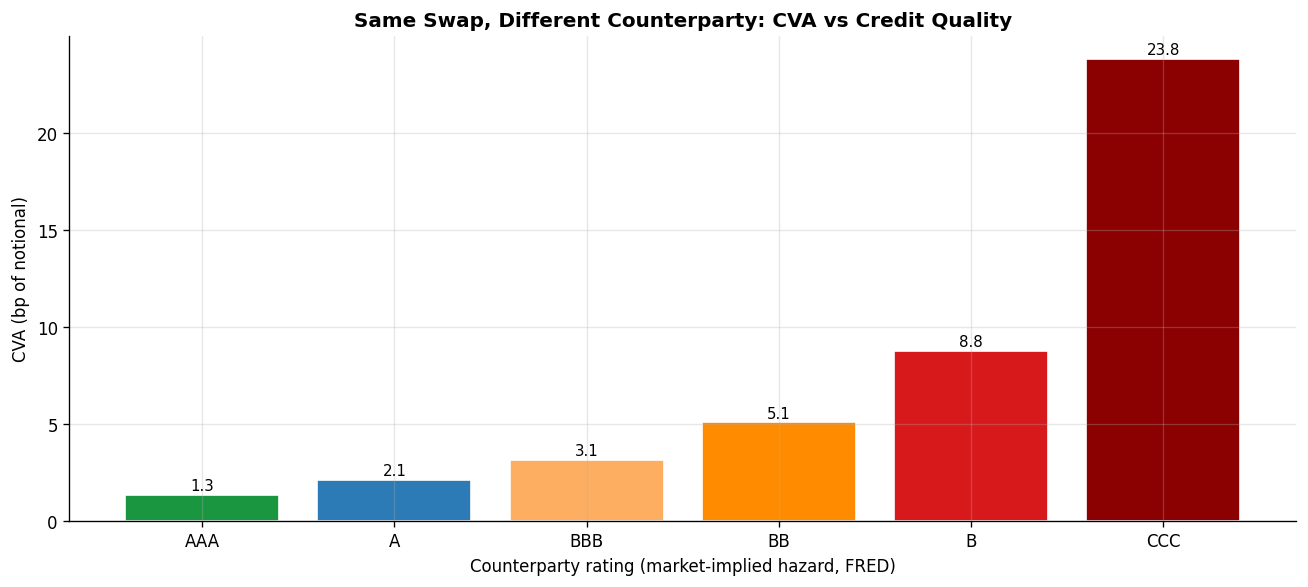


Same trade, same exposure - only the counterparty's credit changes:
  AAA : CVA =  1.33 bp
  A   : CVA =  2.10 bp
  BBB : CVA =  3.12 bp
  BB  : CVA =  5.06 bp
  B   : CVA =  8.76 bp
  CCC : CVA = 23.79 bp

That spread of CVAs IS the counterparty-risk price. Next steps a desk takes:
  - DVA: repeat with expected NEGATIVE exposure and your OWN hazard (a bilateral CVA).
  - Wrong-way risk: let exposure and the counterparty's default correlate (raises CVA).
  - Netting & collateral (CSA): net across trades and post margin to cut EE, hence CVA.


In [24]:
# --- CVA from the real bootstrapped hazard curve, then a sweep across real ratings ---
LGD_CVA = 0.60

def _surv_pw(t):                          # survival from the Section-3 bootstrapped hazard curve
    s=0.0
    for k in range(len(t_knots)-1):
        t0,t1=t_knots[k],t_knots[k+1]
        if t<=t0: break
        s += lam_boot[k]*(min(t,t1)-t0)
    return np.exp(-s)

def cva_for_survival(surv_fn):
    S = np.array([surv_fn(x) for x in np.concatenate([[0.0], edates])])
    dPD = S[:-1] - S[1:]                   # marginal default prob in each interval
    return LGD_CVA * np.sum(EE * dPD * DF)

cva_base = cva_for_survival(_surv_pw)
print(f"Counterparty = the bootstrapped IG credit curve (Section 3):")
print(f"  CVA = {cva_base*1e4:.2f} bp of notional  (risk-free swap value is ~0 at inception,")
print(f"  so this is the credit charge the desk books against the trade).")

# Sweep across the real market credit curve (FRED OAS by rating -> constant hazard)
ratings_cva = list(lam_by_rating.keys())
cva_by_rating = [cva_for_survival(lambda x, lam=lam_by_rating[rt]: np.exp(-lam*x)) for rt in ratings_cva]

fig, ax = plt.subplots(figsize=(11,5))
_pal = [GREEN, BLUE, GOLD, 'darkorange', RED, '#8B0000']
bar_c = [_pal[i % len(_pal)] for i in range(len(ratings_cva))]
bars = ax.bar(ratings_cva, np.array(cva_by_rating)*1e4, color=bar_c, edgecolor='white')
for bar,v in zip(bars, np.array(cva_by_rating)*1e4):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('CVA (bp of notional)'); ax.set_xlabel('Counterparty rating (market-implied hazard, FRED)')
ax.set_title('Same Swap, Different Counterparty: CVA vs Credit Quality', fontweight='bold')
plt.tight_layout(); plt.show()

print("\nSame trade, same exposure - only the counterparty's credit changes:")
for rt, c in zip(ratings_cva, cva_by_rating):
    print(f"  {rt:4s}: CVA = {c*1e4:5.2f} bp")
print("\nThat spread of CVAs IS the counterparty-risk price. Next steps a desk takes:")
print("  - DVA: repeat with expected NEGATIVE exposure and your OWN hazard (a bilateral CVA).")
print("  - Wrong-way risk: let exposure and the counterparty's default correlate (raises CVA).")
print("  - Netting & collateral (CSA): net across trades and post margin to cut EE, hence CVA.")

## 11. IFRS 9: Expected Credit Loss (the number that hits the P&L)

Everything so far measures or prices risk. **IFRS 9** is the accounting rule that turns it into a
line in the financial statements: how much a bank must **provision today** for loans that may not be
repaid. It replaced the old "incurred loss" rule (reserve only once trouble is visible) that proved
*too little, too late* in 2008, with a **forward-looking Expected Credit Loss (ECL)** model: reserve
for losses you expect, from day one, before anyone defaults. (The US equivalent is **CECL**.)

**The three-stage model and the ECL formula:**

- **Stage 1** (healthy): reserve the **12-month** ECL, losses from defaults that could happen in the next year.
- **Stage 2** (credit risk significantly increased, e.g. a downgrade): reserve the **lifetime** ECL, losses over the whole remaining life. This jump is the heart of IFRS 9.
- **Stage 3** (credit-impaired): lifetime ECL, interest on the net amount.

$$\text{ECL} = \sum_{k}\; \underbrace{\text{marginal PD}_k}_{\text{default in year }k}\;\times\;\text{LGD}\;\times\;\text{EAD}_k\;\times\;\text{DF}_k$$

The **lifetime PD term structure** is exactly what a transition matrix gives: raise the **real
one-year S&P matrix** to the power $n$ and read the default column to get the cumulative PD by year
$n$. LGD comes from real recovery; we discount at the loan's effective interest rate (risk-free plus
the rating's real market spread).

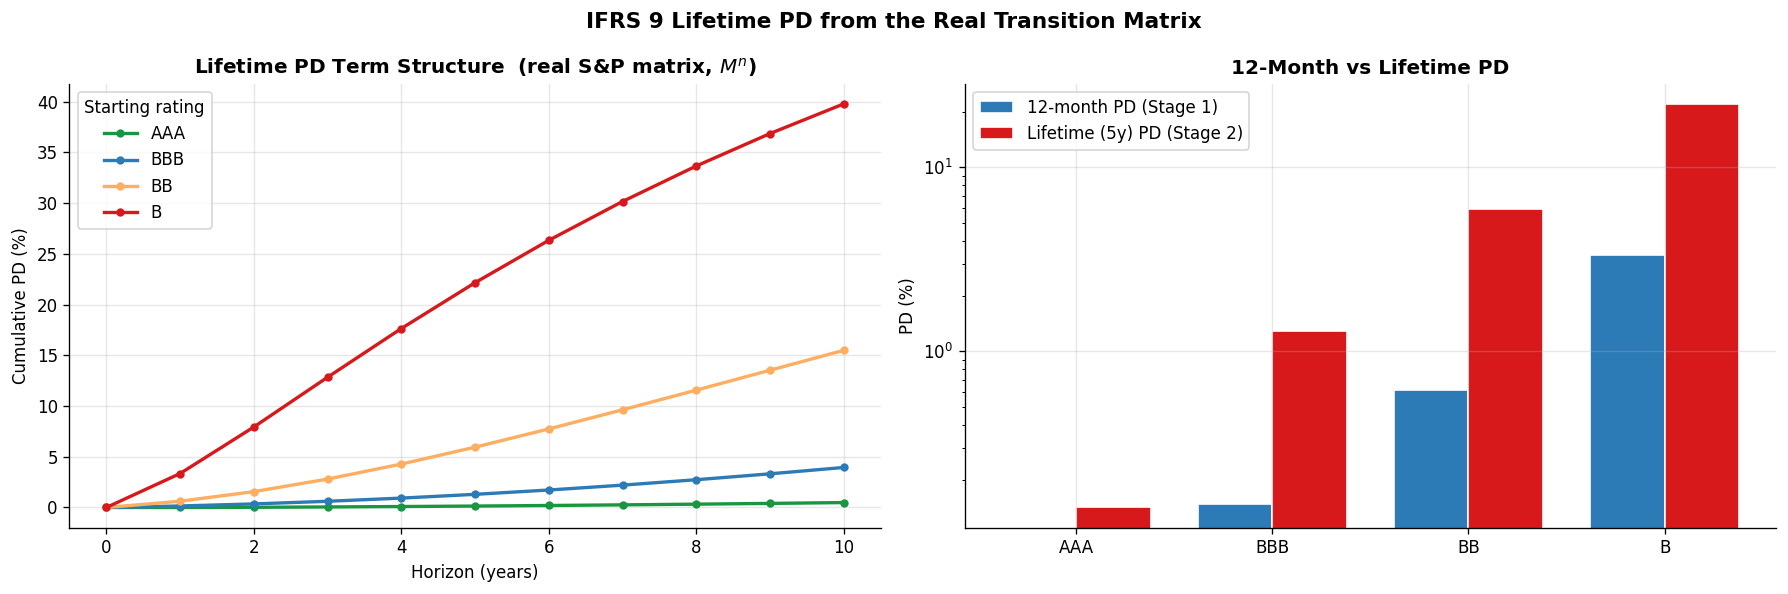

Rating    12m PD  5y cum PD  lifetime multiple
AAA        0.00%      0.14%               n/a
BBB        0.15%      1.30%              8.7x
BB         0.62%      5.94%              9.6x
B          3.35%     22.15%              6.6x


In [25]:
# --- Lifetime PD term structure from the real S&P matrix (matrix powers M^n) ---
# Reuse the transition matrix loaded for CreditMetrics; make an 8x8 Markov chain with D absorbing.
ecl_states = ["AAA","AA","A","BBB","BB","B","CCC/C","D"]
Mmat = np.zeros((8,8))
for i,r in enumerate(ecl_states[:-1]):
    row = cm_trans.loc[r, ecl_states].values.astype(float); Mmat[i,:] = row/row.sum()  # drop NR, renormalise
Mmat[7,7] = 1.0                                                   # default is absorbing

def cum_pd(rating, n):                                            # cumulative PD by year n
    return np.linalg.matrix_power(Mmat, n)[ecl_states.index(rating), 7]

YEARS = np.arange(0, 11)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
curve_ratings = ["AAA","BBB","BB","B"]; ccol=[GREEN, BLUE, GOLD, RED]
for rt, c in zip(curve_ratings, ccol):
    cpd = [cum_pd(rt, n)*100 for n in YEARS]
    axes[0].plot(YEARS, cpd, 'o-', color=c, lw=2, ms=4, label=rt)
axes[0].set_xlabel("Horizon (years)"); axes[0].set_ylabel("Cumulative PD (%)")
axes[0].set_title("Lifetime PD Term Structure  (real S&P matrix, $M^n$)", fontweight='bold')
axes[0].legend(title="Starting rating")

pd12  = [cum_pd(rt,1)*100 for rt in curve_ratings]
pd5y  = [cum_pd(rt,5)*100 for rt in curve_ratings]
x = np.arange(len(curve_ratings)); w=0.38
axes[1].bar(x-w/2, pd12, w, label="12-month PD (Stage 1)", color=BLUE, edgecolor='white')
axes[1].bar(x+w/2, pd5y, w, label="Lifetime (5y) PD (Stage 2)", color=RED, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(curve_ratings); axes[1].set_yscale('log')
axes[1].set_ylabel("PD (%)"); axes[1].set_title("12-Month vs Lifetime PD", fontweight='bold'); axes[1].legend()
plt.suptitle("IFRS 9 Lifetime PD from the Real Transition Matrix", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'Rating':7s} {'12m PD':>8s} {'5y cum PD':>10s} {'lifetime multiple':>18s}")
for rt in curve_ratings:
    p1, p5 = cum_pd(rt,1), cum_pd(rt,5)
    mult = f"{p5/p1:.1f}x" if p1 > 0 else "n/a"
    print(f"{rt:7s} {p1*100:7.2f}% {p5*100:9.2f}% {mult:>17s}")

$1,000,000 5-year loan, LGD 60%  (real S&P PDs, discounted at risk-free + market spread)
  Stage 1  (12-month ECL, BBB)                 : $     847
  Stage 2  (lifetime ECL, still BBB)           : $   6,541   (7.7x  <- staging alone)
  Stage 2  (lifetime ECL, downgraded to BB)    : $  29,389   (34.7x  <- staging + downgrade)

A loan that has NOT missed a single payment sees its provision jump ~35x the day it
moves to Stage 2. That is the forward-looking reserve IFRS 9 forces banks to hold in advance.


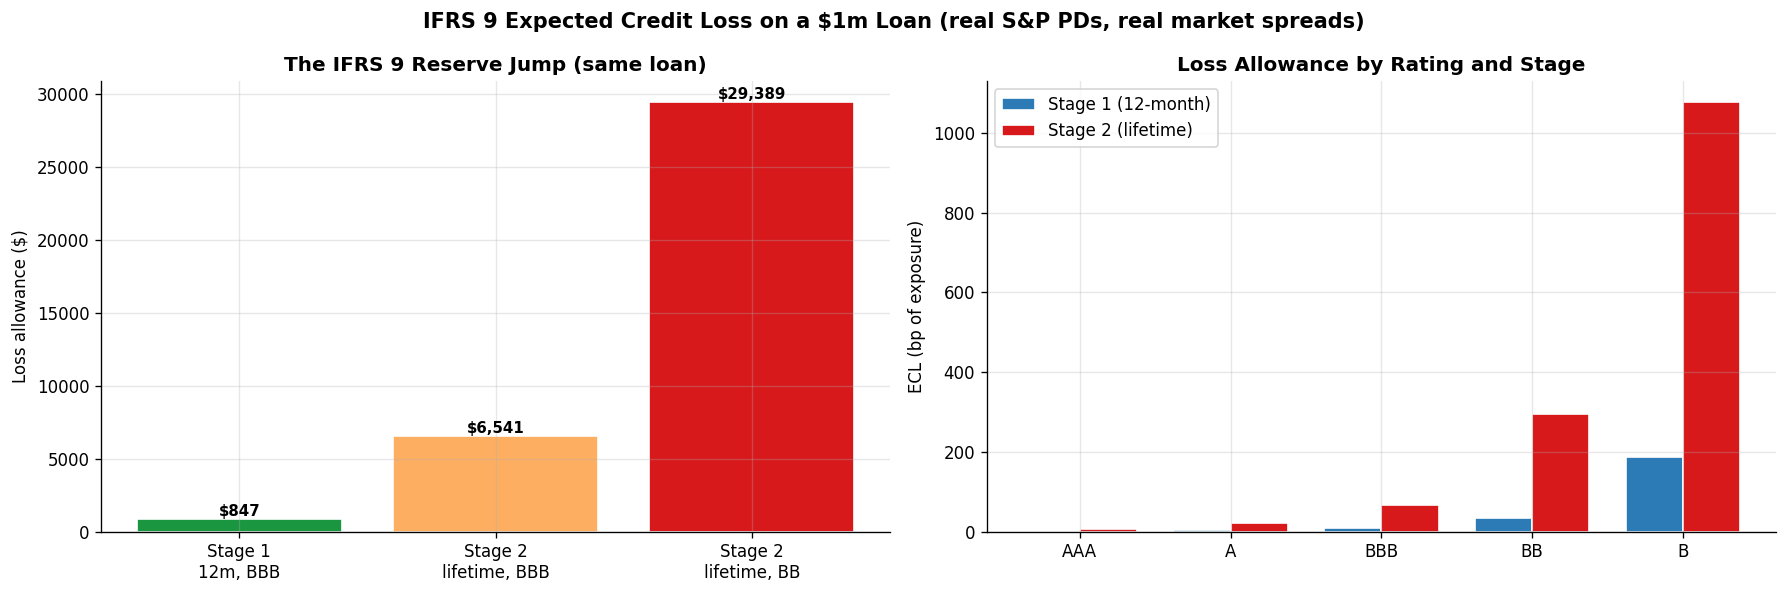

In [26]:
# --- ECL on a sample loan: the Stage 1 -> Stage 2 reserve jump ---
_fr = fred_spreads().dropna(how='all').iloc[-1]
oas_of = {'AAA':'AAA','AA':'AA','A':'A_','BBB':'BBB','BB':'BB','B':'B','CCC/C':'CCC'}
LGD_ECL, EAD, T_LOAN = 0.60, 1_000_000, 5          # 60% LGD, $1m exposure, 5y bullet loan
rf = fred_rf(T_LOAN)     # risk-free = 5y Treasury (FRED, DGS5) for the 5-year loan

def ecl(rating, stage):
    eir = rf + float(_fr[oas_of[rating]])/100                 # effective interest rate for discounting
    if stage == 1:                                            # 12-month ECL
        return cum_pd(rating,1) * LGD_ECL * EAD / (1+eir)
    loss = 0.0                                                # lifetime ECL
    for k in range(1, T_LOAN+1):
        mpd = cum_pd(rating,k) - cum_pd(rating,k-1)           # marginal PD in year k
        loss += mpd * LGD_ECL * EAD / (1+eir)**k
    return loss

# A $1m 5-year loan booked at BBB, then a "significant increase in credit risk" (downgrade to BB)
s1_bbb  = ecl("BBB", 1)     # Stage 1: 12-month ECL, still BBB
s2_bbb  = ecl("BBB", 2)     # Stage 2: lifetime ECL, same BBB rating (pure staging effect)
s2_bb   = ecl("BB",  2)     # Stage 2: lifetime ECL after the downgrade to BB

print(f"$1,000,000 5-year loan, LGD {LGD_ECL:.0%}  (real S&P PDs, discounted at risk-free + market spread)")
print("="*68)
print(f"  Stage 1  (12-month ECL, BBB)                 : ${s1_bbb:8,.0f}")
print(f"  Stage 2  (lifetime ECL, still BBB)           : ${s2_bbb:8,.0f}   ({s2_bbb/s1_bbb:.1f}x  <- staging alone)")
print(f"  Stage 2  (lifetime ECL, downgraded to BB)    : ${s2_bb:8,.0f}   ({s2_bb/s1_bbb:.1f}x  <- staging + downgrade)")
print(f"\nA loan that has NOT missed a single payment sees its provision jump ~{s2_bb/s1_bbb:.0f}x the day it")
print("moves to Stage 2. That is the forward-looking reserve IFRS 9 forces banks to hold in advance.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar(["Stage 1\n12m, BBB","Stage 2\nlifetime, BBB","Stage 2\nlifetime, BB"],
                   [s1_bbb, s2_bbb, s2_bb], color=[GREEN, GOLD, RED], edgecolor='white')
for b,v in zip(bars,[s1_bbb,s2_bbb,s2_bb]):
    axes[0].text(b.get_x()+b.get_width()/2, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel("Loss allowance ($)"); axes[0].set_title("The IFRS 9 Reserve Jump (same loan)", fontweight='bold')

# ECL by rating: 12-month vs lifetime, as basis points of exposure
rr = ["AAA","A","BBB","BB","B"]
e12 = [ecl(r,1)/EAD*1e4 for r in rr]; elife=[ecl(r,2)/EAD*1e4 for r in rr]
x=np.arange(len(rr)); w=0.38
axes[1].bar(x-w/2, e12, w, label="Stage 1 (12-month)", color=BLUE, edgecolor='white')
axes[1].bar(x+w/2, elife, w, label="Stage 2 (lifetime)", color=RED, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(rr); axes[1].set_ylabel("ECL (bp of exposure)")
axes[1].set_title("Loss Allowance by Rating and Stage", fontweight='bold'); axes[1].legend()
plt.suptitle("IFRS 9 Expected Credit Loss on a $1m Loan (real S&P PDs, real market spreads)",
             fontsize=12.5, fontweight='bold'); plt.tight_layout(); plt.show()

## 12. Spread Relative Value: Mean Reversion and the Crossover Trade

Everything so far measures *how much* credit risk a portfolio carries. This section is about the
other half of a credit PM's job: deciding **which credits are cheap or rich right now**. The core
tool (Fabozzi Ch.20) is simple: **mean-reversion analysis**. Spreads move around
a long-run average; a spread far above its mean is "cheap" (buy it, you expect it to tighten), far below
is "rich" (sell it).

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">The z-score signal</div>
<div style="color:#B8D4E8;line-height:1.7;">
For each rating bucket, z = (current spread - mean spread) / stdev over the sample. z &gt; +1 = cheap
(historically wide); z &lt; -1 = rich (historically tight). We also watch the <strong>quality spread</strong>:
the gap between a low- and a high-quality bucket (e.g. BB minus BBB). It collapses in expansions
and blows out in stress; buying the lower-quality bucket when the quality spread is wide and expected
to compress is the <strong>crossover / credit-upside trade</strong>.
</div></div>

*Data: ICE BofA OAS history by rating, pulled live from FRED (the most recent three years of daily data, a full recent credit cycle).*

Spread relative value by rating bucket  (ICE BofA OAS, 2026-07-10)
     current_bp  mean_bp  sd_bp     z  pctile       signal
AAA        40.0     38.0    6.0  0.43    74.0         fair
AA         55.0     52.0    7.0  0.40    73.0         fair
A          64.0     77.0   14.0 -0.95    15.0         fair
BBB        96.0    115.0   18.0 -1.03     9.0  RICH (sell)
BB        159.0    197.0   34.0 -1.10     3.0  RICH (sell)
B         287.0    325.0   48.0 -0.80    17.0         fair
CCC       970.0    886.0   81.0  1.03    89.0  CHEAP (buy)

Mean-reversion read: a positive z means today's spread sits above its own cycle average
(historically cheap); negative z means richer (tighter) than average. Percentile is the rank of today's
spread within the full 2021-2026 sample.

Crossover quality spread  BB - BBB : now 63 bp | mean 82 bp | z = -1.05
Wide-and-expected-to-compress -> overweight BBB/BB into an upturn (the credit-upside trade).


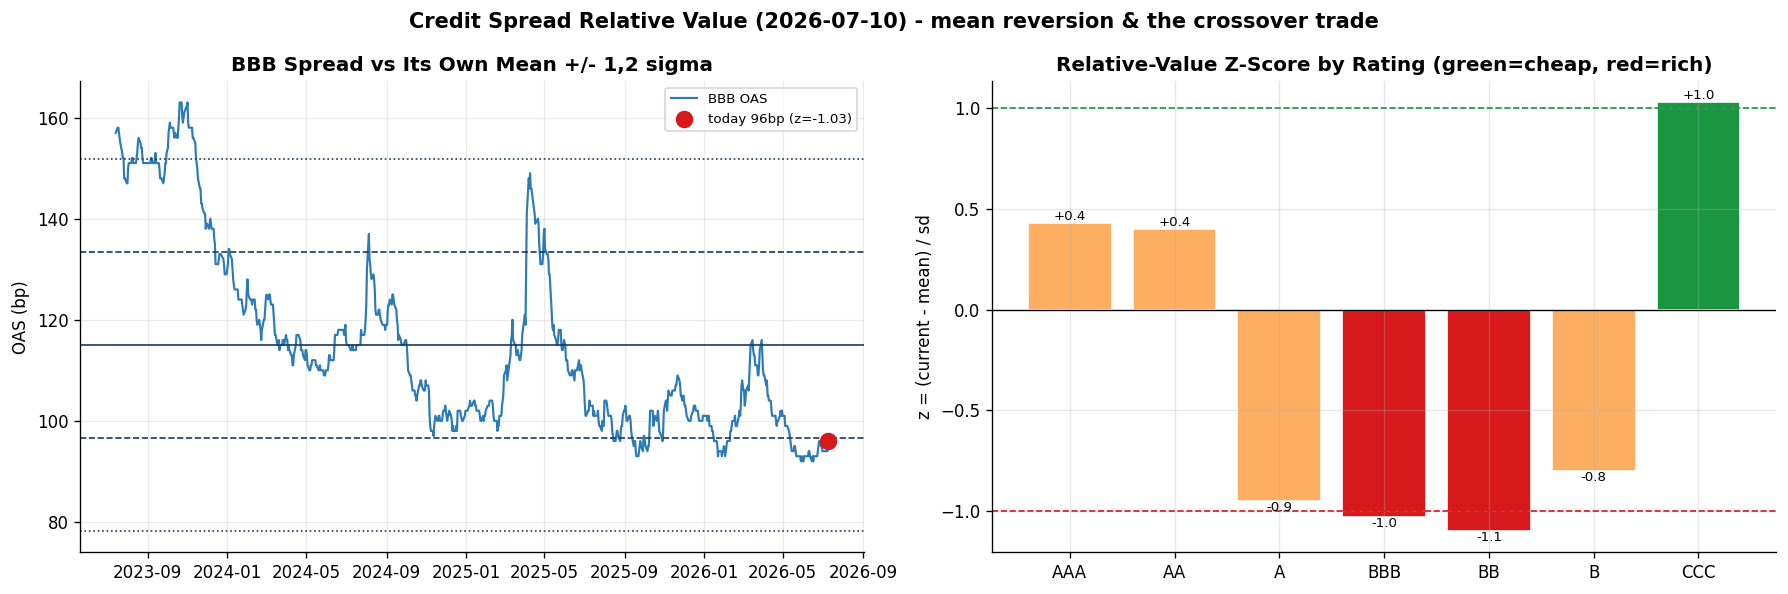


Secondary-trade rationales this signal feeds (Fabozzi Ch.20):
  - yield/spread pickup : rotate into the CHEAP buckets for carry
  - credit-upside / crossover : buy BB/BBB when the quality spread is wide, ride the compression
  - credit-defense : lighten RICH buckets where there is little spread cushion left
  - sector rotation : same z-score logic applied across industries, not just ratings


In [27]:
# --- Spread mean-reversion & relative value from the real FRED OAS history ---
hist = fred_spreads().dropna(how="all")
rate_cols = {"AAA":"AAA","AA":"AA","A":"A_","BBB":"BBB","BB":"BB","B":"B","CCC":"CCC"}
S = hist[list(rate_cols.values())].rename(columns={v:k for k,v in rate_cols.items()}) * 100  # bps
asof = S.index[-1].date()

# z-score of each bucket's current spread vs its own full-sample history
tbl = pd.DataFrame({
    "current_bp": S.iloc[-1].round(0),
    "mean_bp":    S.mean().round(0),
    "sd_bp":      S.std().round(0),
})
tbl["z"] = ((S.iloc[-1] - S.mean()) / S.std()).round(2)
tbl["pctile"] = (S.rank(pct=True).iloc[-1] * 100).round(0)
def verdict(z):
    return "CHEAP (buy)" if z >= 1 else ("RICH (sell)" if z <= -1 else "fair")
tbl["signal"] = tbl["z"].apply(verdict)

print(f"Spread relative value by rating bucket  (ICE BofA OAS, {asof})")
print(tbl.to_string())
print("\nMean-reversion read: a positive z means today's spread sits above its own cycle average")
print("(historically cheap); negative z means richer (tighter) than average. Percentile is the rank of today's")
print("spread within the full 2021-2026 sample.")

# quality (crossover) spread: BB minus BBB - the classic investment-grade / high-yield boundary
qs = S["BB"] - S["BBB"]
qs_z = (qs.iloc[-1] - qs.mean()) / qs.std()
print(f"\nCrossover quality spread  BB - BBB : now {qs.iloc[-1]:.0f} bp | mean {qs.mean():.0f} bp | "
      f"z = {qs_z:+.2f}")
print("Wide-and-expected-to-compress -> overweight BBB/BB into an upturn (the credit-upside trade).")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Panel 1: BBB OAS with mean +/- 1,2 sigma bands and today's marker
bbb = S["BBB"]; m, sd = bbb.mean(), bbb.std()
axes[0].plot(bbb.index, bbb.values, color=BLUE, lw=1.3, label="BBB OAS")
for k, ls in [(0,"-"),(1,"--"),(2,":")]:
    axes[0].axhline(m+k*sd, color=NAVY, lw=1, ls=ls)
    if k: axes[0].axhline(m-k*sd, color=NAVY, lw=1, ls=ls)
axes[0].scatter([bbb.index[-1]],[bbb.iloc[-1]], s=90, color=RED, zorder=5,
                label=f"today {bbb.iloc[-1]:.0f}bp (z={tbl.loc['BBB','z']:+.2f})")
axes[0].set_title("BBB Spread vs Its Own Mean +/- 1,2 sigma", fontweight="bold")
axes[0].set_ylabel("OAS (bp)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)
# Panel 2: z-score bar across buckets
z = tbl["z"]; cols = [RED if v<=-1 else (GREEN if v>=1 else GOLD) for v in z]
axes[1].bar(z.index, z.values, color=cols, edgecolor="white")
axes[1].axhline(0, color="black", lw=0.8); axes[1].axhline(1, color=GREEN, lw=1, ls="--")
axes[1].axhline(-1, color=RED, lw=1, ls="--")
axes[1].set_title("Relative-Value Z-Score by Rating (green=cheap, red=rich)", fontweight="bold")
axes[1].set_ylabel("z = (current - mean) / sd")
for i,v in enumerate(z.values): axes[1].text(i, v, f"{v:+.1f}", ha="center",
                                             va="bottom" if v>=0 else "top", fontsize=8)
plt.suptitle(f"Credit Spread Relative Value ({asof}) - mean reversion & the crossover trade",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

print("\nSecondary-trade rationales this signal feeds (Fabozzi Ch.20):")
print("  - yield/spread pickup : rotate into the CHEAP buckets for carry")
print("  - credit-upside / crossover : buy BB/BBB when the quality spread is wide, ride the compression")
print("  - credit-defense : lighten RICH buckets where there is little spread cushion left")
print("  - sector rotation : same z-score logic applied across industries, not just ratings")

### Long-history check: Moody's Baa spreads over several cycles

The z-scores above use the ICE BofA OAS series, which FRED only serves for about the last three
years, so they measure "cheap or rich" against a single recent cycle. Moody's seasoned Aaa and Baa
corporate yields go back to **1986**, so we can z-score the investment-grade credit spread over four
decades and several recessions (1990-91, 2001, 2008, 2020, 2022). Two long-history measures, both
pulled live from FRED:

- **Baa minus 10-year Treasury** (`BAA10Y`): the headline IG credit spread.
- **Baa minus Aaa** (`DBAA - DAAA`): the quality spread, the classic credit-cycle gauge.

A spread that looks average against three years can look rich or cheap against forty.

Long-history spread z-scores (Moody's, 1986-01-02 to 2026-07-09, 10,129 daily obs, several cycles):
  Baa minus 10y Treasury   now  156 bp | mean  227 | sd  69 | z -1.02 |  10th pct | RICH (tight)
  Baa minus Aaa quality    now   42 bp | mean   95 | sd  36 | z -1.49 |   0th pct | RICH (tight)
The mean and bands here reflect the 1990-91, 2001, 2008, 2020 and 2022 episodes, so a spread
that screens normal against three years can screen rich or cheap against four decades.


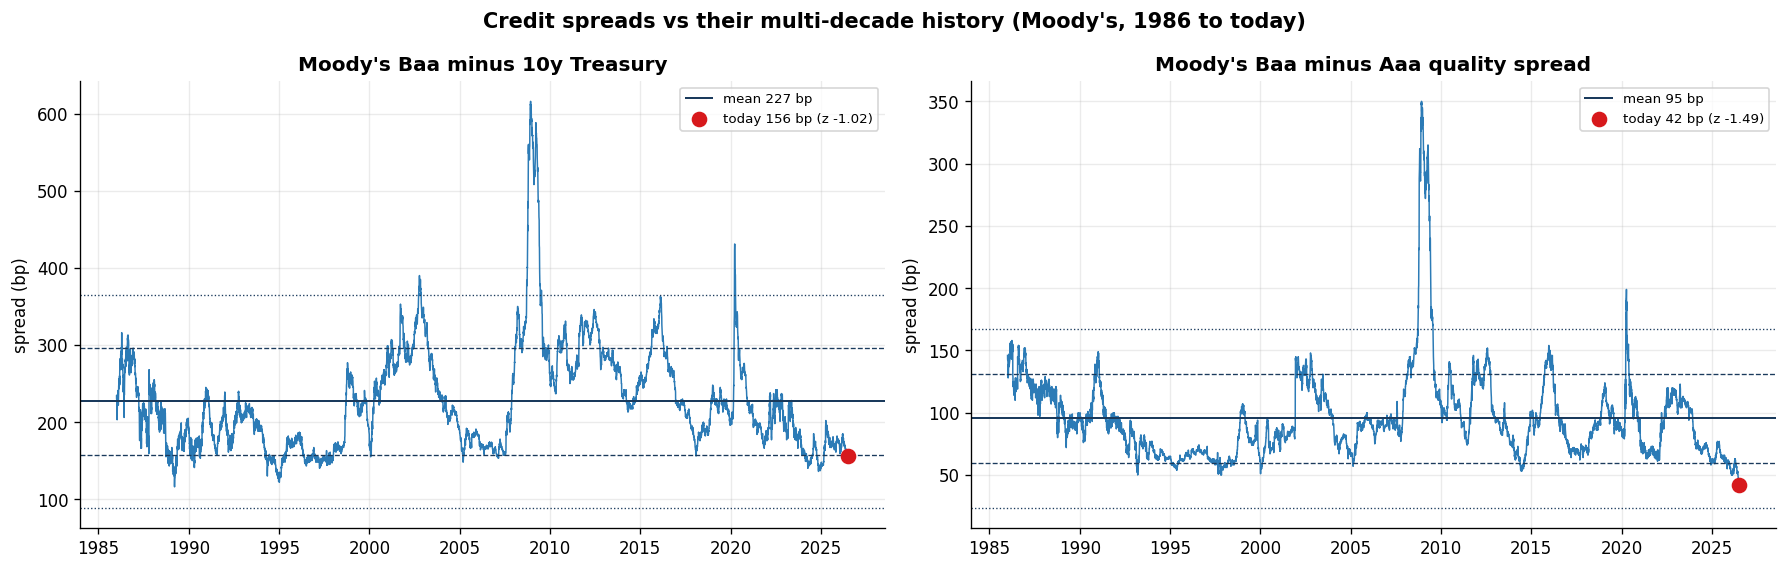

In [28]:
# --- Long-history mean reversion: Moody's Baa spreads over several cycles (1986 to today) ---
# ICE BofA OAS on FRED only reach back ~3 years; Moody's seasoned Aaa/Baa yields reach back to 1986,
# so these z-scores span several credit cycles, not one. All pulled live from FRED.
baa10   = fred_history("BAA10Y")            # Moody's Baa yield minus 10y Treasury (IG credit spread, % pts)
dbaa    = fred_history("DBAA")              # Moody's seasoned Baa corporate yield (%)
daaa    = fred_history("DAAA")              # Moody's seasoned Aaa corporate yield (%)
quality = (dbaa - daaa).dropna()            # Baa minus Aaa quality spread (% pts)

def _z(s, name):
    cur, mu, sd = s.iloc[-1], s.mean(), s.std()
    z   = (cur - mu) / sd
    pct = s.rank(pct=True).iloc[-1] * 100
    verdict = "CHEAP (wide)" if z >= 1 else ("RICH (tight)" if z <= -1 else "near normal")
    print(f"  {name:24s} now {cur*100:4.0f} bp | mean {mu*100:4.0f} | sd {sd*100:3.0f} | "
          f"z {z:+.2f} | {pct:3.0f}th pct | {verdict}")
    return cur, mu, sd, z

asof = baa10.index[-1].date()
print(f"Long-history spread z-scores (Moody's, {baa10.index[0].date()} to {asof}, "
      f"{len(baa10):,} daily obs, several cycles):")
zb = _z(baa10,   "Baa minus 10y Treasury")
zq = _z(quality, "Baa minus Aaa quality")
print("The mean and bands here reflect the 1990-91, 2001, 2008, 2020 and 2022 episodes, so a spread")
print("that screens normal against three years can screen rich or cheap against four decades.")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, (s, ttl, zt) in zip(axes,
        [(baa10, "Moody's Baa minus 10y Treasury", zb),
         (quality, "Moody's Baa minus Aaa quality spread", zq)]):
    cur, mu, sd, z = zt
    ax.plot(s.index, s.values*100, color=BLUE, lw=0.9)
    ax.axhline(mu*100, color=NAVY, lw=1.2, label=f"mean {mu*100:.0f} bp")
    for k, ls in [(1, "--"), (2, ":")]:
        ax.axhline((mu+k*sd)*100, color=NAVY, lw=0.8, ls=ls)
        ax.axhline((mu-k*sd)*100, color=NAVY, lw=0.8, ls=ls)
    ax.scatter([s.index[-1]], [cur*100], s=70, color=RED, zorder=5,
               label=f"today {cur*100:.0f} bp (z {z:+.2f})")
    ax.set_title(ttl, fontweight="bold"); ax.set_ylabel("spread (bp)")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.suptitle("Credit spreads vs their multi-decade history (Moody's, 1986 to today)",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

## 13. Transferring Credit Risk: Total-Return Swaps & Basket Default Swaps

Single-name CDS (Section 3) transfers the default risk of one issuer. Two broader instruments extend
that (Fabozzi Ch.24):

<div style="border-left:5px solid #2E86C1;background:#0D2B45;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#2E86C1;font-weight:700;margin-bottom:7px;">Total-return swap (TRS)</div>
<div style="color:#B8D4E8;line-height:1.7;">
The <strong>total-return receiver</strong> gets every cash flow <em>and</em> the price change of a
reference bond, and pays a floating rate (e.g. LIBOR + spread). It is a way to go long
credit without funding it. But the receiver takes on <strong>both</strong> credit-spread risk and interest-rate risk,
so a correct spread call can still lose money if the benchmark curve moves against you.</div>
</div>

<div style="border-left:5px solid #C0392B;background:#2B0D0D;padding:14px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#E74C3C;font-weight:700;margin-bottom:7px;">Basket / Nth-to-default swaps</div>
<div style="color:#E8B8B8;line-height:1.7;">
Protection on a small basket that pays only when the <strong>N-th</strong> name defaults. Their
pricing is <strong>all about default correlation</strong>: the same one-factor copula from Section 4.
The key point: <strong>first-to-default protection gets cheaper as correlation rises</strong> (names
default together, so "at least one" becomes less likely in any given period), while
<strong>senior / second-and-later-to-default protection gets more expensive</strong> (clustering makes
multiple joint defaults more likely). This is the equity-vs-senior-tranche CDO lesson in miniature.
</div></div>

Total-return swap: PM is the total-return RECEIVER (long credit), pays benchmark + 140bp.
Reference: 7.5% 10y bond bought at par, spread 300bp, $10,000,000 notional.

1-yr scenario                           new ytm   bond P    coupon  price chg   funding  NET to receiver
spread tightens 50bp, rates flat         7.04%   103.25   754,000    325,208  -594,000          485,208
spread tightens 50bp, rates +100bp       8.04%    96.88   754,000   -311,826  -594,000         -151,826
spread widens 100bp (credit sours)       8.54%    93.89   754,000   -610,901  -594,000         -450,901

Row 2 is the trap: the credit view was RIGHT (spread tightened) yet the receiver LOSES, because
the +100bp benchmark move dominates. TRS bundles credit-DEPENDENT and credit-INDEPENDENT rate
risk; to isolate the pure credit view you would swap on the spread change only, or hedge duration.


Basket default swaps on a 5-name basket (5-yr, per-name PD from real market hazards):
  per-name 5y PD: A 7.7%, B 12.4%, C 1

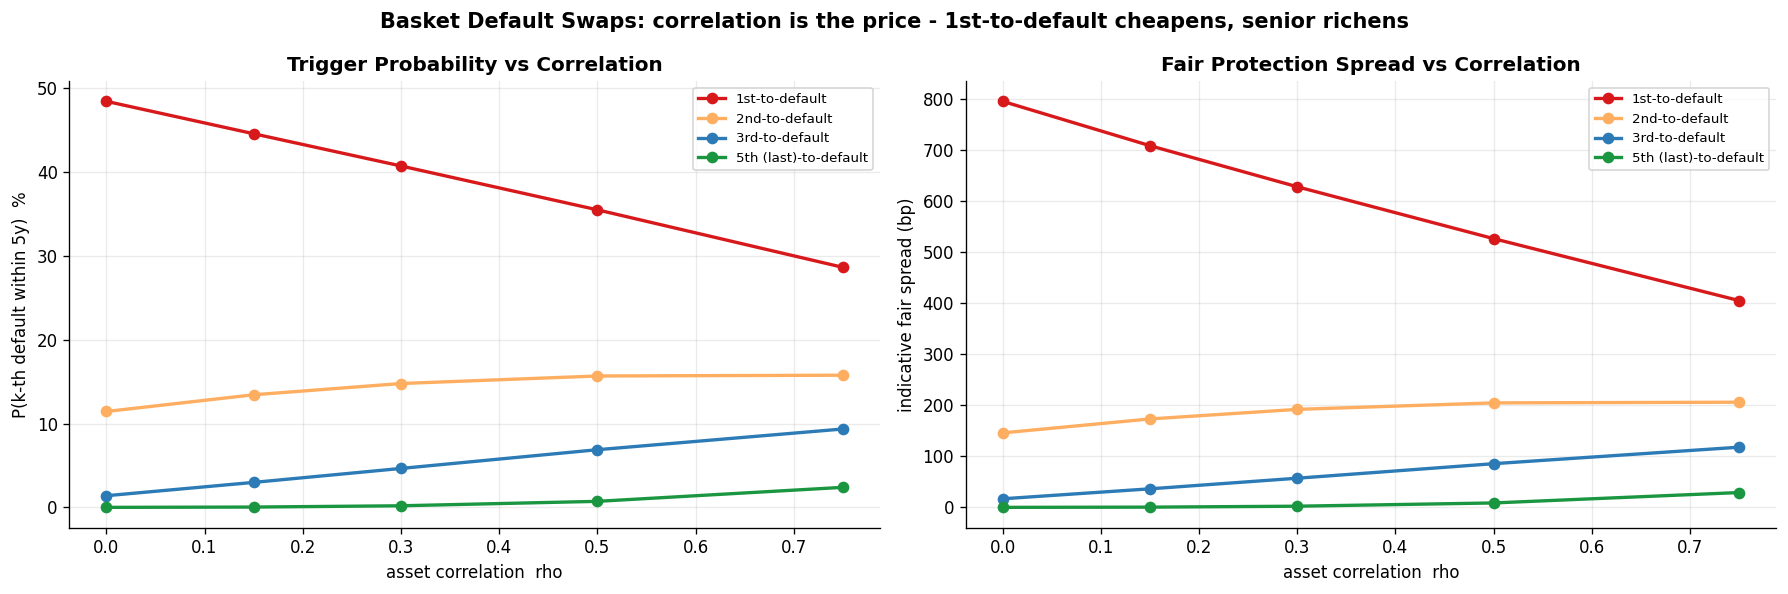


The correlation lesson: as rho rises the first-to-default spread FALLS (defaults bunch, so
'at least one' is less likely in any window) while the 5th/senior spread RISES (joint blow-ups
get more likely). A first-to-default seller is short correlation; a senior-basket seller is long
it - exactly the equity vs senior CDO-tranche trade-off from Section 7, now as a traded contract.


In [29]:
# ============ Part A: Total-return swap - the twin-risk trap ============
def bond_price(coupon, ytm, n, face=100.0, freq=1):
    c = coupon*face/freq; y = ytm/freq; N = n*freq
    return sum(c/(1+y)**t for t in range(1,N+1)) + face/(1+y)**N

rf = fred_rf(10)                                # benchmark = 10y Treasury (FRED, DGS10) for the 10y bond
MAT, FACE = 10, 10_000_000
bench0, spread0 = rf, 0.030                     # benchmark = live 10y Treasury, credit spread 300bp
COUP = bench0 + spread0                         # par bond: coupon = benchmark + spread, so it starts at par
fund = bench0 + 0.014                           # receiver pays benchmark + 140bp funding
print("Total-return swap: PM is the total-return RECEIVER (long credit), pays benchmark + 140bp.")
print(f"Reference: {COUP:.1%} 10y bond bought at par, spread {spread0*1e4:.0f}bp, ${FACE:,.0f} notional.\n")
print(f"{'1-yr scenario':38s}{'new ytm':>9s}{'bond P':>9s}{'coupon':>10s}{'price chg':>11s}"
      f"{'funding':>10s}{'NET to receiver':>17s}")
for name, d_spread, d_bench in [("spread tightens 50bp, rates flat", -0.005, 0.0),
                                ("spread tightens 50bp, rates +100bp", -0.005, 0.010),
                                ("spread widens 100bp (credit sours)",  0.010, 0.0)]:
    ytm1 = (bench0+d_bench) + (spread0+d_spread)
    P1 = bond_price(COUP, ytm1, MAT-1); dP = (P1-100)/100*FACE
    coupon_rec = COUP*FACE; funding_pay = fund*FACE
    net = coupon_rec + dP - funding_pay
    print(f"{name:38s}{ytm1:>8.2%}{P1:>9.2f}{coupon_rec:>10,.0f}{dP:>11,.0f}"
          f"{-funding_pay:>10,.0f}{net:>17,.0f}")
print("\nRow 2 is the trap: the credit view was RIGHT (spread tightened) yet the receiver LOSES, because")
print("the +100bp benchmark move dominates. TRS bundles credit-DEPENDENT and credit-INDEPENDENT rate")
print("risk; to isolate the pure credit view you would swap on the spread change only, or hedge duration.")

# ============ Part B: Basket / Nth-to-default priced off the copula ============
# A 5-name basket; per-name 5-year default prob from the real market hazards (Section 2).
T_BSK = 5.0
basket = [("Name A (BBB)", lam_by_rating["BBB"]), ("Name B (BB)", lam_by_rating["BB"]),
          ("Name C (BB)",  lam_by_rating["BB"]),  ("Name D (B)",  lam_by_rating["B"]),
          ("Name E (BBB)", lam_by_rating["BBB"])]
pd_names = np.array([1-np.exp(-lam*T_BSK) for _,lam in basket])
thr = norm.ppf(pd_names)                                  # copula default thresholds
LGD_BSK = 0.60; n_sim = 300_000
rhos = [0.0, 0.15, 0.30, 0.50, 0.75]

def basket_probs(rho, seed=7):
    rng = np.random.default_rng(seed)
    M = rng.standard_normal(n_sim)
    A = np.sqrt(rho)*M[:,None] + np.sqrt(1-rho)*rng.standard_normal((n_sim,5))
    K = (A < thr).sum(axis=1)                             # number of defaults in the basket
    # P(k-th default occurs within horizon) = P(K >= k)
    return np.array([(K>=k).mean() for k in range(1,6)]), K.mean()

print("\n\nBasket default swaps on a 5-name basket (5-yr, per-name PD from real market hazards):")
print("  per-name 5y PD:", ", ".join(f"{nm.split()[1]} {p*100:.1f}%" for (nm,_),p in zip(basket,pd_names)))
print(f"\n{'rho':>5s} | {'E[#def]':>8s} | " + " ".join(f"{'P(>='+str(k)+')':>9s}" for k in range(1,6))
      + " | " + " ".join(f"{'s'+str(k):>7s}" for k in range(1,6)))
rows=[]
for rho in rhos:
    P, meanK = basket_probs(rho)
    # indicative running fair spread of the k-th-to-default (bp): LGD * annualised trigger hazard
    spr = LGD_BSK * (-np.log(np.clip(1-P,1e-9,1))/T_BSK) * 1e4
    rows.append((rho,P,spr))
    print(f"{rho:>5.2f} | {meanK:>8.3f} | " + " ".join(f"{p*100:>8.2f}%" for p in P)
          + " | " + " ".join(f"{s:>7.0f}" for s in spr))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
Ps = np.array([r[1] for r in rows])            # rho x k trigger probabilities
for k,lab,col in [(1,"1st-to-default",RED),(2,"2nd-to-default",GOLD),
                  (3,"3rd-to-default",BLUE),(5,"5th (last)-to-default",GREEN)]:
    axes[0].plot(rhos, Ps[:,k-1]*100, "o-", color=col, lw=2, label=lab)
axes[0].set_xlabel("asset correlation  rho"); axes[0].set_ylabel("P(k-th default within 5y)  %")
axes[0].set_title("Trigger Probability vs Correlation", fontweight="bold")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)
Ss = np.array([r[2] for r in rows])
for k,lab,col in [(1,"1st-to-default",RED),(2,"2nd-to-default",GOLD),
                  (3,"3rd-to-default",BLUE),(5,"5th (last)-to-default",GREEN)]:
    axes[1].plot(rhos, Ss[:,k-1], "o-", color=col, lw=2, label=lab)
axes[1].set_xlabel("asset correlation  rho"); axes[1].set_ylabel("indicative fair spread (bp)")
axes[1].set_title("Fair Protection Spread vs Correlation", fontweight="bold")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)
plt.suptitle("Basket Default Swaps: correlation is the price - 1st-to-default cheapens, senior richens",
             fontsize=12.5, fontweight="bold"); plt.tight_layout(); plt.show()

print("\nThe correlation lesson: as rho rises the first-to-default spread FALLS (defaults bunch, so")
print("'at least one' is less likely in any window) while the 5th/senior spread RISES (joint blow-ups")
print("get more likely). A first-to-default seller is short correlation; a senior-basket seller is long")
print("it - exactly the equity vs senior CDO-tranche trade-off from Section 7, now as a traded contract.")

## Summary

| Model | Type | Key idea | This session |
|-------|------|----------|--------------|
| **Intensity / reduced-form** | Single name | Default = first Poisson jump, $S(T)=e^{-\lambda T}$ | $\lambda$ from real FRED spreads |
| **CDS bootstrap** | Single name | Back hazard curve out of the spread term structure | Real IG OAS by maturity |
| **Gaussian copula** | Portfolio (default) | One-factor asset correlation drives joint default | Loss dist. & Credit VaR |
| **Vasicek** | Portfolio (default) | Large-pool analytic limit of the copula | Basel IRB formula |
| **CreditMetrics** | Portfolio (migration) | Revalue over all rating moves, not just default | Real S&P matrix + spreads |
| **CreditRisk+** | Portfolio (actuarial) | Gamma-mixed Poisson on PD + exposure only | Tail vs copula/Vasicek |
| **CVA** | Counterparty (pricing) | Charge for a counterparty defaulting on a derivative | EE profile x real hazard curve |
| **IFRS 9 ECL** | Accounting (provisioning) | Forward-looking loss allowance, PD x LGD x EAD | Lifetime PD from real $M^n$ |

<div style="border-left:5px solid #D4A017;background:#1C1400;padding:13px 20px;border-radius:0 8px 8px 0;margin:12px 0;">
<div style="color:#D4A017;font-weight:700;margin-bottom:6px;">The one lesson to keep</div>
<div style="color:#F5CBA7;line-height:1.7;">Every portfolio model here says the same thing from a different direction: <strong>expected loss is
easy; the tail is all about correlation.</strong> Whether you dial asset correlation (copula/Vasicek),
model rating migration (CreditMetrics), or default-rate volatility (CreditRisk+), a modest amount of
co-movement is what turns a "safe" senior position into the 2008 outcome.</div>
</div>

<sub>Yuriy Zabolotnyuk  ·  Sprott School of Business  ·  Carleton University</sub>

---
## Your Turn: Portfolio Credit Risk Exercise

<div style="background:#e8f4e8; border-left: 5px solid #1A9641; padding: 14px 18px; border-radius: 5px;">
<b style="color:#1a3a5c;">Exercise Instructions</b><br>
Using the one-factor Gaussian copula framework from this notebook, 
simulate a portfolio loss distribution for <b>your own chosen parameters</b> 
and compute the key credit risk metrics. Then answer the interpretation questions.
</div>

### Part A: Parameter Setup
Choose your own portfolio parameters:
- `MY_N`   : number of obligors (suggest 50 to 200)
- `MY_PD`  : annual probability of default (e.g. 0.02 = 2%)
- `MY_LGD` : loss given default (e.g. 0.40 = 40%)
- `MY_RHO` : asset correlation (e.g. 0.20 = 20%)
- `MY_NSIM`: number of Monte Carlo scenarios (≥ 50,000 for stable tail estimates)

### Part B: Simulate the Loss Distribution
Use `simulate_portfolio_loss()` (already defined above) with your parameters.
Plot the full distribution with EL, 99% VaR, and 99% ES marked.

### Part C: Credit VaR and ES
Compute and print:
- Expected Loss (EL)
- 99% VaR and Credit VaR (= 99% VaR minus EL)
- 99% ES
- Compare to the Vasicek analytical 99% VaR (use `vasicek_var()`).

### Part D: Correlation Sensitivity
Run your simulation for three values of `MY_RHO`: your base value, half of it, and double it 
(cap at 0.60). Plot the three loss distributions on one chart and produce a table of 
EL, 99% VaR, 99% ES for each ρ.

### Part E: Interpretation
Answer in a markdown cell (2 to 4 sentences each):
1. How does the shape of the loss distribution change as ρ increases? Why?
2. If this pool were structured into a CDO with a senior tranche attaching at 3× EL, 
   would the senior tranche be safe at your base ρ? What if ρ doubles?
3. What are two limitations of the Gaussian copula for portfolio credit risk?


In [30]:
# ── Part A: Set your parameters ──────────────────────────────────────────────
MY_N    = 100    # number of obligors
MY_PD   = 0.02   # 2% annual PD
MY_LGD  = 0.40   # 40% LGD
MY_RHO  = 0.20   # 20% asset correlation
MY_NSIM = 100_000

# YOUR CODE HERE


In [31]:
# ── Part B: Simulate and plot the loss distribution ──────────────────────────

# YOUR CODE HERE


In [32]:
# ── Part C: Credit VaR, ES, and Vasicek comparison ───────────────────────────

# YOUR CODE HERE


In [33]:
# ── Part D: Correlation sensitivity table and chart ───────────────────────────

# YOUR CODE HERE


### Part E: Interpretation

Answer in a short markdown cell:
1. How does your 99.9% Credit VaR change as correlation $\rho$ rises? Why does **expected loss** stay flat?
2. Compare your Monte Carlo Credit VaR with the **Vasicek** analytic value. When do they agree?
3. **Migration vs default:** would a **CreditMetrics** (mark-to-market) view give a higher or lower
   one-year risk figure than your default-only simulation for an investment-grade book? Why?
4. **Model choice:** you have a granular retail pool with reliable PDs but no asset prices. Which of
   the six models in the summary table would you reach for, and what does that buy you?